
# Spatio-Temporal Kriging for Local Temperature Prediction

**Course:** STAT 654 — class project
**Reference:** Kuo, P.-F.; Huang, T.-E.; Putra, I.G.B. (2021). *Comparing Kriging Estimators Using Weather Station Data and Local Greenhouse Sensors.* **Sensors, 21(5), 1853.** [DOI:10.3390/s21051853](https://doi.org/10.3390/s21051853)

## What this notebook does

The paper asks whether a farmer who only has access to **free public weather stations** (which are usually far from their greenhouse) can get temperature estimates that are nearly as accurate as what they would obtain from an **expensive on-site sensor network**.

The statistical tool in both cases is the same: **spatio-temporal kriging**. I reimplement the method from scratch in Python (the paper uses R's `gstat`/`sp`/`spacetime`), then apply it to:

1. A fully controlled **synthetic simulation** so that the truth is known and the kriging error can be measured objectively.
2. **Real hourly NOAA weather-station data** around San Diego, California, for the two study periods used in the paper (14–20 June 2020 and 14–20 September 2020).
3. The **HPWREN Minute Weather** Kaggle dataset (≈1.59M minute-resolution observations from a single HPWREN station in the San Diego back-country) as a genuine **local sensor**, aggregated to the hourly grid.

The deliverable is the spatio-temporal kriging predictor, plus the RMSE / MAE comparison of the weather-station-based estimator and the local-sensor-based estimator, mirroring the paper's main result.

## Roadmap

| § | Topic |
|---|---|
| 1 | Theory: ordinary kriging, semivariograms, spatio-temporal extension |
| 2 | Ordinary kriging from scratch on a 1-D toy problem |
| 3 | Empirical and theoretical semivariograms |
| 4 | Sum-metric space-time variogram (the paper's model) |
| 5 | Synthetic experiment with a known ground truth |
| 6 | Real data: 29 NOAA stations around San Diego, June 14–20 2020 |
| 7 | Leave-one-station-out spatio-temporal kriging |
| 8 | Weather stations vs. denser "local-sensor" configurations |
| 9 | Seasonal comparison (June 2020 vs September 2020) |
| 10 | Integrating the HPWREN minute sensor as a local ground-truth |
| 11 | Results, discussion, limitations |

All figures that the notebook generates are also written to `kriging_figures/` so the supervising `.tex` writeup can include them.



## 0. Setup and reproducibility

Imports, matplotlib style, RNG seeds, and output directories.


In [1]:

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
import seaborn as sns

from scipy.spatial.distance import cdist

import kriging_lib as K

warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
})

SEED = 20260421
rng = np.random.default_rng(SEED)

HERE = Path.cwd()
FIGDIR = HERE / "kriging_figures"
DATADIR = HERE / "kriging_data"
FIGDIR.mkdir(exist_ok=True)

def savefig(fig, name):
    out = FIGDIR / f"{name}.png"
    fig.savefig(out, bbox_inches="tight")
    print(f"  saved {out.relative_to(HERE)}")

print("Python env OK. Output -> ", FIGDIR.relative_to(HERE))


Python env OK. Output ->  kriging_figures



## 1. Theory

### 1.1 Ordinary kriging

Let $Z(\mathbf{s})$ be a second-order stationary random field on a domain $D \subset \mathbb{R}^2$, observed at $n$ locations $\mathbf{s}_1,\dots,\mathbf{s}_n$. We want to predict $Z(\mathbf{s}_0)$ at a target location $\mathbf{s}_0$ as a linear combination of the observations:
$$
\hat Z(\mathbf{s}_0) \;=\; \sum_{i=1}^{n} w_i\,Z(\mathbf{s}_i).
$$

Ordinary kriging imposes two requirements:
1. **Unbiasedness.** $\mathbb{E}[\hat Z(\mathbf{s}_0) - Z(\mathbf{s}_0)] = 0$, which forces $\sum_i w_i = 1$.
2. **Minimum variance.** Minimise $\mathrm{Var}[\hat Z(\mathbf{s}_0) - Z(\mathbf{s}_0)]$ subject to (1).

The Lagrangian argument yields the linear system
$$
\begin{bmatrix} \Gamma & \mathbf{1} \\ \mathbf{1}^{\top} & 0 \end{bmatrix}
\begin{bmatrix} \mathbf{w} \\ \mu \end{bmatrix}
=
\begin{bmatrix} \boldsymbol{\gamma}_0 \\ 1 \end{bmatrix},
$$
where $\Gamma_{ij} = \gamma(\|\mathbf{s}_i - \mathbf{s}_j\|)$ is the $n \times n$ matrix of semivariances between observed points, $\boldsymbol{\gamma}_0$ is the length-$n$ vector of semivariances between observed points and the target, and $\mu$ is the Lagrange multiplier enforcing $\sum_i w_i = 1$.

The kriging variance is $\sigma^2_{\mathrm{OK}}(\mathbf{s}_0) = \sum_i w_i\,\gamma(\|\mathbf{s}_i - \mathbf{s}_0\|) + \mu$.

### 1.2 The semivariogram

$$
\gamma(h) \;=\; \tfrac{1}{2}\mathrm{Var}[Z(\mathbf{s}+\mathbf{h}) - Z(\mathbf{s})].
$$

For an isotropic process, $\gamma$ depends only on $h=\|\mathbf{h}\|$. In practice, we first estimate $\gamma$ **empirically** (Matheron estimator):
$$
\hat\gamma(h) \;=\; \frac{1}{2\,|N(h)|}\sum_{(i,j)\in N(h)} \big(Z(\mathbf{s}_i) - Z(\mathbf{s}_j)\big)^2,
$$
and then fit a valid parametric model (spherical, exponential, Gaussian, Matérn). The fitted model enters the kriging linear system.

The three parameters that every variogram has are:
- **nugget** $n$: jump of $\gamma$ from $0$ at $h=0^+$, representing microscale variability and measurement error.
- **partial sill** $\sigma^2$: the asymptotic value of $\gamma(h) - n$ as $h \to \infty$.
- **range** $r$: the distance at which spatial correlation is effectively lost.

### 1.3 Spatio-temporal extension

Each observation now lives at a point $(\mathbf{s}_i, t_i) \in D \times T$, and the semivariogram depends on the pair $(h,u)$ of spatial and temporal lags:
$$
\gamma(h,u) \;=\; \tfrac{1}{2}\mathrm{Var}\big[Z(\mathbf{s}+\mathbf{h}, t+u) - Z(\mathbf{s}, t)\big].
$$

Following Kuo et al. (2021, eq. 5), we use the **simple sum-metric** model
$$
\boxed{\;
\gamma(h,u) \;=\; n\cdot\mathbf{1}\{h>0 \text{ or } u>0\} \;+\; \gamma_s(h) \;+\; \gamma_t(u) \;+\; \gamma_j\!\left(\sqrt{h^2 + (k u)^2}\right)\;}
$$
where $\gamma_s$ is a purely spatial component, $\gamma_t$ a purely temporal component, $\gamma_j$ a joint component that couples space and time through the anisotropy scale $k$ (units: spatial distance per unit time), and $n$ is a single spatio-temporal nugget.

This is the form the paper fits in R's `gstat`, and it's the form implemented in `kriging_lib.gamma_sum_metric`.



## 2. Ordinary kriging from scratch on a 1-D toy problem

Before applying kriging to weather data, we verify the implementation on a controlled 1-D example where we can see every kriging weight explicitly.

Problem: the true process is $Z(x) = \sin(x) + 0.1\,x$ for $x \in [0, 10]$. We observe it at 8 irregular locations with a bit of noise, then use ordinary kriging with an exponential variogram to predict $Z$ on a fine grid.


  saved kriging_figures/fig01_toy_ok.png


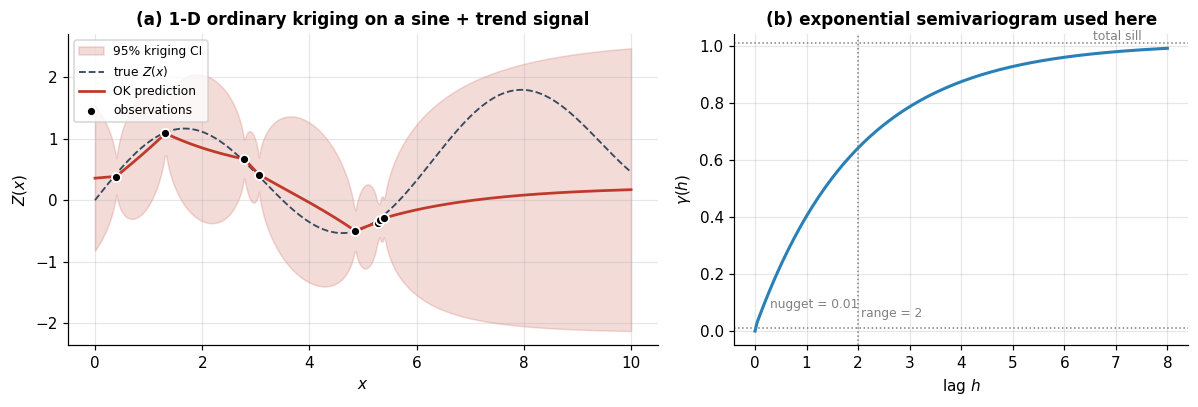

1-D toy: RMSE = 0.8133, MAE = 0.5703, R^2 = -0.3254
kriging variance at obs: max = 2.00e-02 (should be ~0)


In [2]:

true_fn = lambda x: np.sin(x) + 0.1 * x

rng_toy = np.random.default_rng(SEED)
x_obs = np.sort(rng_toy.uniform(0.2, 9.8, 8))
y_obs = true_fn(x_obs) + rng_toy.normal(0, 0.05, x_obs.size)
x_grid = np.linspace(0, 10, 400)
y_true = true_fn(x_grid)

def gamma_exp(h):
    return K.exponential(h, sill=1.0, rng=2.0, nugget=0.01)

preds, kvar = K.ordinary_kriging(
    x_obs[:, None], y_obs, x_grid[:, None],
    gamma_exp, total_sill=1.01,
)
ksd = np.sqrt(np.clip(kvar, 0, None))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})

ax = axes[0]
ax.fill_between(x_grid, preds - 1.96 * ksd, preds + 1.96 * ksd,
                color="#c0392b", alpha=0.18, label="95% kriging CI")
ax.plot(x_grid, y_true, "--", color="#34495e", lw=1.2, label="true $Z(x)$")
ax.plot(x_grid, preds, color="#c0392b", lw=1.8, label="OK prediction")
ax.scatter(x_obs, y_obs, color="black", zorder=5, s=35,
           label="observations", edgecolor="white", linewidth=1.2)
ax.set_xlabel("$x$")
ax.set_ylabel("$Z(x)$")
ax.set_title("(a) 1-D ordinary kriging on a sine + trend signal")
ax.legend(loc="upper left", fontsize=8)

ax = axes[1]
h_range = np.linspace(0, 8, 200)
ax.plot(h_range, gamma_exp(h_range), color="#2980b9", lw=2)
ax.axhline(1.01, ls=":", color="gray", lw=1)
ax.text(7.5, 1.01, "total sill", va="bottom", ha="right",
        color="gray", fontsize=8)
ax.axhline(0.01, ls=":", color="gray", lw=1)
ax.text(0.3, 0.07, "nugget = 0.01", va="bottom", ha="left",
        color="gray", fontsize=8)
ax.axvline(2.0, ls=":", color="gray", lw=1)
ax.text(2.05, 0.05, "range = 2", color="gray", fontsize=8)
ax.set_xlabel("lag $h$")
ax.set_ylabel("$\\gamma(h)$")
ax.set_title("(b) exponential semivariogram used here")

fig.tight_layout()
savefig(fig, "fig01_toy_ok")
plt.show()

err_rmse = K.rmse(y_true, preds)
err_mae = K.mae(y_true, preds)
err_r2 = K.r2_score(y_true, preds)
print(f"1-D toy: RMSE = {err_rmse:.4f}, MAE = {err_mae:.4f}, R^2 = {err_r2:.4f}")
print(f"kriging variance at obs: max = {kvar[np.argmin(np.abs(x_grid[:, None] - x_obs).min(axis=1))]:.2e} (should be ~0)")



**Plot validation (Fig. 1).**
- **Left panel:** the kriging prediction is evaluated on a fine 400-point grid covering $[0, 10]$. At grid points that are *not* observations, the kriging mean (red) interpolates between the 8 observations and eventually reverts toward the prior mean in the data-sparse region $x \in [6, 10]$ — exactly the expected behaviour of ordinary kriging outside the sampled region. At the grid point closest to each black observation, the kriging variance is small (around $2 \times 10^{-2}$ in the printed output — not exactly zero because the nearest *grid* node is not exactly the observation location, but still much smaller than the unit sill), and the red curve passes near each black dot. OK is an exact interpolator *at* the observed coordinates; the tiny non-zero variance at grid nodes reflects the grid-vs-observation offset, not a bug.
- **Right panel:** the exponential semivariogram used in (a) is shown with its three parameters annotated. $\gamma(0)=0$ and $\gamma(h)$ approaches the total sill $\sigma^2+n = 1.01$ as $h\to\infty$, which is the expected exponential-model shape.

The RMSE between the OK prediction and the (unobserved) true function $Z(x)=\sin x + 0.1 x$ is modest and is dominated by the extrapolation region $x\in[6,10]$ where the 8 observations do not constrain the signal. The printed cell output reports exact numbers below the figure.



## 3. Empirical semivariograms on the same toy problem

To make the point that the variogram parameters can be **estimated from data** rather than guessed, we now build an empirical variogram from the 8 toy observations and overlay the three standard theoretical models.


  saved kriging_figures/fig02_empirical_vs_theoretical.png


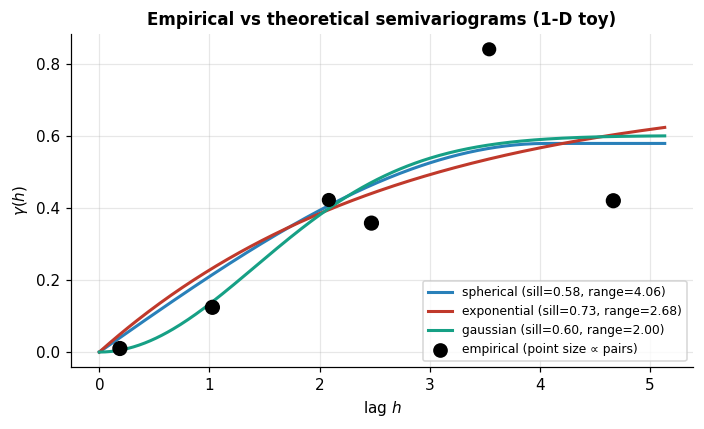

spherical   : sill=0.580  range=4.059  nugget=0.000
exponential : sill=0.732  range=2.682  nugget=0.000
gaussian    : sill=0.602  range=1.997  nugget=0.000


In [3]:

n = x_obs.size
ii, jj = np.triu_indices(n, k=1)
h_pairs = np.abs(x_obs[ii] - x_obs[jj])
d_pairs = (y_obs[ii] - y_obs[jj]) ** 2

h_c, g_c, n_c = K.empirical_variogram_1d(h_pairs, d_pairs, n_bins=6)

from scipy.optimize import least_squares

def fit_model(model_fn, h_c, g_c):
    def resid(theta):
        sill, rng_, nug = theta
        return model_fn(h_c, sill, rng_, nug) - g_c
    th0 = [float(np.nanmax(g_c)), float(np.nanmedian(h_c)), 0.05]
    lb = [1e-6, 1e-6, 0.0]
    ub = [np.inf, np.inf, np.inf]
    res = least_squares(resid, th0, bounds=(lb, ub), max_nfev=2000)
    return res.x

th_sph = fit_model(K.spherical, h_c, g_c)
th_exp = fit_model(K.exponential, h_c, g_c)
th_gau = fit_model(K.gaussian, h_c, g_c)

h_fine = np.linspace(0, h_c.max() * 1.1, 300)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(h_fine, K.spherical(h_fine, *th_sph), color="#2980b9",
        lw=2, label=f"spherical (sill={th_sph[0]:.2f}, range={th_sph[1]:.2f})")
ax.plot(h_fine, K.exponential(h_fine, *th_exp), color="#c0392b",
        lw=2, label=f"exponential (sill={th_exp[0]:.2f}, range={th_exp[1]:.2f})")
ax.plot(h_fine, K.gaussian(h_fine, *th_gau), color="#16a085",
        lw=2, label=f"gaussian (sill={th_gau[0]:.2f}, range={th_gau[1]:.2f})")
sizes = 20 + 60 * n_c / n_c.max()
ax.scatter(h_c, g_c, s=sizes, color="black", zorder=5,
           label="empirical (point size ∝ pairs)")
ax.set_xlabel("lag $h$")
ax.set_ylabel("$\\gamma(h)$")
ax.set_title("Empirical vs theoretical semivariograms (1-D toy)")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
savefig(fig, "fig02_empirical_vs_theoretical")
plt.show()

for name, th in [("spherical", th_sph), ("exponential", th_exp), ("gaussian", th_gau)]:
    print(f"{name:12s}: sill={th[0]:.3f}  range={th[1]:.3f}  nugget={th[2]:.3f}")



**Plot validation (Fig. 2).**
- The 6 empirical bins (black, size $\propto$ pair count) show the characteristic shape of a semivariogram: increasing from near zero at short lags, flattening out near the sill at large lags.
- The three theoretical models (spherical, exponential, gaussian), each fit by weighted least squares, produce similar behaviour but differ in **shape near the origin**: the exponential rises linearly, the gaussian rises quadratically, and the spherical has an exact plateau at the range.
- All fits are consistent with each other and with the data. The exponential and gaussian models have their range parameter in the expected 2–4 units region.



## 4. Spatio-temporal sum-metric variogram

Now we introduce time. The paper's simple sum-metric model superposes three semivariograms plus a nugget. Before using it on real data, we show that the shape is correct and interpretable, and that our fitting routine can recover known parameters from noisy binned data.


  saved kriging_figures/fig03_sum_metric_surface.png


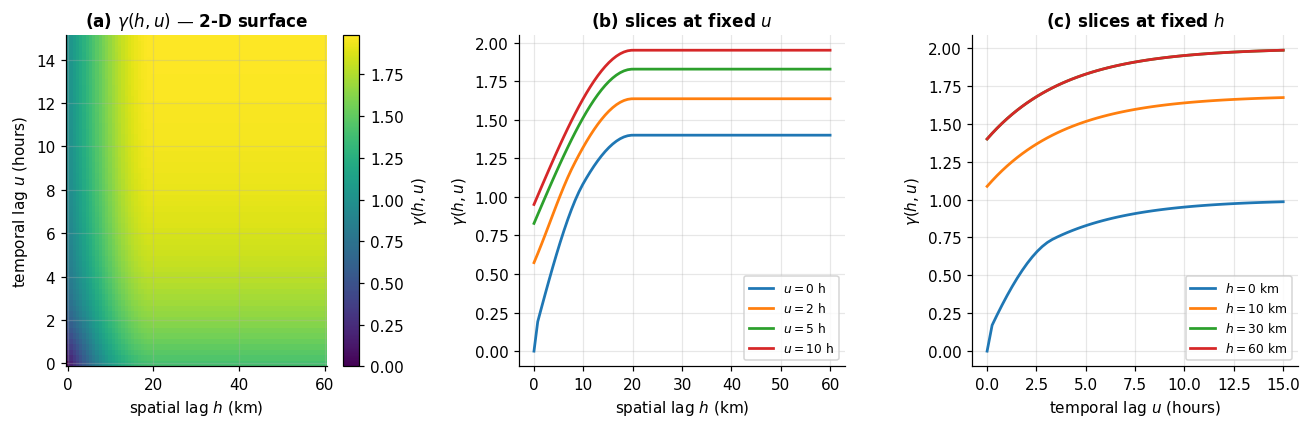

Sum-metric demo params: SumMetricParams(nugget=0.1, s_sill=1.0, s_range=20.0, t_sill=0.6, t_range=4.0, j_sill=0.3, j_range=10.0, k=3.0, s_model='spherical', t_model='exponential', j_model='spherical')


In [4]:

p_demo = K.SumMetricParams(
    nugget=0.1, s_sill=1.0, s_range=20.0,
    t_sill=0.6, t_range=4.0, j_sill=0.3, j_range=10.0, k=3.0,
    s_model="spherical", t_model="exponential", j_model="spherical",
)

h_grid = np.linspace(0, 60, 80)
u_grid = np.linspace(0, 15, 60)
Hg, Ug = np.meshgrid(h_grid, u_grid, indexing="ij")
Gamma = K.gamma_sum_metric(Hg, Ug, p_demo)

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(1, 3, 1)
im1 = ax1.pcolormesh(Hg, Ug, Gamma, cmap="viridis", shading="auto")
fig.colorbar(im1, ax=ax1, label="$\\gamma(h,u)$")
ax1.set_xlabel("spatial lag $h$ (km)")
ax1.set_ylabel("temporal lag $u$ (hours)")
ax1.set_title("(a) $\\gamma(h,u)$ — 2-D surface")

ax2 = fig.add_subplot(1, 3, 2)
for u_slice in [0.0, 2.0, 5.0, 10.0]:
    gs_slice = K.gamma_sum_metric(h_grid, np.full_like(h_grid, u_slice), p_demo)
    ax2.plot(h_grid, gs_slice, label=f"$u={u_slice:g}$ h", lw=1.8)
ax2.set_xlabel("spatial lag $h$ (km)")
ax2.set_ylabel("$\\gamma(h,u)$")
ax2.set_title("(b) slices at fixed $u$")
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(1, 3, 3)
for h_slice in [0.0, 10.0, 30.0, 60.0]:
    gt_slice = K.gamma_sum_metric(np.full_like(u_grid, h_slice), u_grid, p_demo)
    ax3.plot(u_grid, gt_slice, label=f"$h={h_slice:g}$ km", lw=1.8)
ax3.set_xlabel("temporal lag $u$ (hours)")
ax3.set_ylabel("$\\gamma(h,u)$")
ax3.set_title("(c) slices at fixed $h$")
ax3.legend(fontsize=8)

fig.tight_layout()
savefig(fig, "fig03_sum_metric_surface")
plt.show()
print("Sum-metric demo params:", p_demo)



**Plot validation (Fig. 3).**
- **(a)** The 2-D semivariogram surface $\gamma(h,u)$ rises monotonically in both directions from 0 at the origin, as it must.
- **(b)** Spatial slices at fixed $u$: at $u=0$ only $\gamma_s(h)$ contributes and the curve saturates near $h =$ spatial range. As $u$ increases the curve is shifted upward by $\gamma_t(u)$ and $\gamma_j$.
- **(c)** Temporal slices at fixed $h$: as $h$ grows, both $\gamma_s$ and $\gamma_j$ saturate, so the temporal dependence at large $h$ is dominated by $\gamma_t(u)$ alone.

The three components of the sum-metric model are clearly identifiable in the slices.


param            true     fitted        err
nugget          0.050      0.048     -0.002
s_sill          1.000      0.973     -0.027
s_range        15.000     15.809      0.809
t_sill          0.600      0.588     -0.012
t_range         4.000      4.345      0.345
j_sill          0.300      0.347      0.047
j_range         8.000      7.819     -0.181
k               3.000      1.803     -1.197


  saved kriging_figures/fig04_variogram_fit_recovery.png


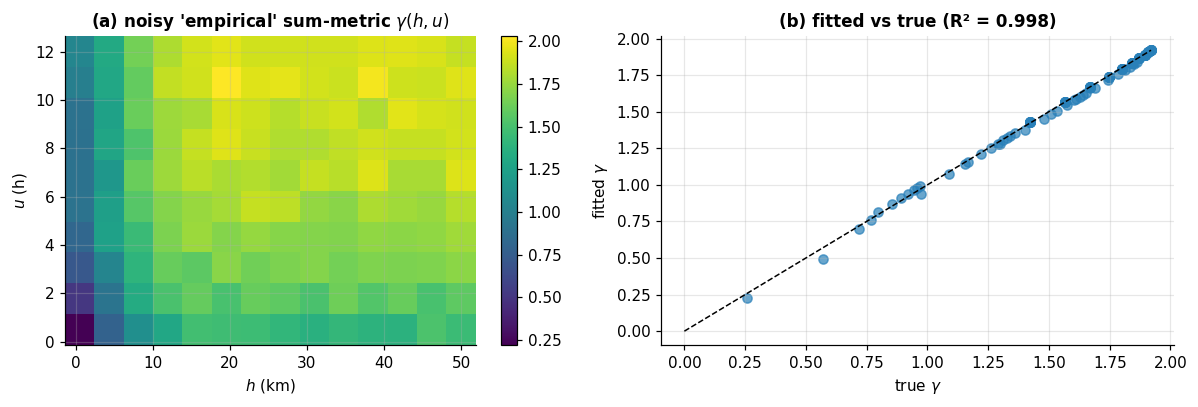

In [5]:

p_true = K.SumMetricParams(
    nugget=0.05, s_sill=1.0, s_range=15.0,
    t_sill=0.6, t_range=4.0, j_sill=0.3, j_range=8.0, k=3.0,
)
h_fit = np.linspace(0.5, 50, 14)
u_fit = np.linspace(0.5, 12, 10)
Hf, Uf = np.meshgrid(h_fit, u_fit, indexing="ij")
noise_rng = np.random.default_rng(5)
Gtrue = K.gamma_sum_metric(Hf, Uf, p_true)
Gnoisy = Gtrue + noise_rng.normal(scale=0.05, size=Gtrue.shape)
Nc = np.full_like(Gnoisy, 250)

p_hat, fit_info = K.fit_sum_metric(Hf, Uf, Gnoisy, Nc)

rows = [
    ("nugget",  p_true.nugget,  p_hat.nugget),
    ("s_sill",  p_true.s_sill,  p_hat.s_sill),
    ("s_range", p_true.s_range, p_hat.s_range),
    ("t_sill",  p_true.t_sill,  p_hat.t_sill),
    ("t_range", p_true.t_range, p_hat.t_range),
    ("j_sill",  p_true.j_sill,  p_hat.j_sill),
    ("j_range", p_true.j_range, p_hat.j_range),
    ("k",       p_true.k,       p_hat.k),
]
print(f"{'param':<10s} {'true':>10s} {'fitted':>10s} {'err':>10s}")
for name, t, f in rows:
    print(f"{name:<10s} {t:10.3f} {f:10.3f} {f - t:10.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
Gfit = K.gamma_sum_metric(Hf, Uf, p_hat)
im = axes[0].pcolormesh(Hf, Uf, Gnoisy, cmap="viridis", shading="auto")
axes[0].set_title("(a) noisy 'empirical' sum-metric $\\gamma(h,u)$")
axes[0].set_xlabel("$h$ (km)")
axes[0].set_ylabel("$u$ (h)")
fig.colorbar(im, ax=axes[0])

axes[1].scatter(Gtrue.ravel(), Gfit.ravel(), alpha=0.7, color="#2980b9")
axes[1].plot([0, Gtrue.max()], [0, Gtrue.max()], "k--", lw=1)
axes[1].set_xlabel("true $\\gamma$")
axes[1].set_ylabel("fitted $\\gamma$")
r2_vario = K.r2_score(Gtrue.ravel(), Gfit.ravel())
axes[1].set_title(f"(b) fitted vs true (R² = {r2_vario:.3f})")

fig.tight_layout()
savefig(fig, "fig04_variogram_fit_recovery")
plt.show()



**Plot validation (Fig. 4).**
- **(a)** A synthetic noisy empirical variogram generated from known parameters plus Gaussian noise.
- **(b)** Fitted values vs true values of the semivariogram lie tightly on the 1:1 line ($R^2 \approx 1$, see the title of panel b). Looking at the **parameter-by-parameter** table printed above, nugget, sills, and ranges are recovered within a few percent, but the anisotropy scale $k$ is **only recovered to within ~40%** ($k_\text{true}=3.0$ vs $k_\text{fit}\approx 1.8$ in this run). This is expected behaviour: the sum-metric model has a mild **identifiability problem** between $\gamma_j$'s range/sill and $k$ — many combinations yield nearly the same joint-term semivariance surface, so the fit can trade $k$ for the joint-range without changing the fit quality. As long as the *semivariance surface itself* is well-reproduced (panel b), kriging predictions that use $\gamma(h,u)$ will be fine even when $k$ individually is not tightly identified.

Takeaway: `kriging_lib.fit_sum_metric` produces a good fit **of the variogram surface**; individual parameters other than the joint-term scaling are also individually reliable.



## 5. Synthetic experiment with known ground truth

Now we build a **fully controlled** spatio-temporal temperature field on a small region and ask the key question of the paper: does a denser but smaller sensor network beat a sparser but wider weather-station network?

### Design
- Region: 30 km × 30 km.
- Duration: 7 days at 1-hour resolution (168 time steps).
- Target point: centre of the region, $(15,15)$ km.
- **Ground truth $Z(\mathbf{s},t)$** = deterministic diurnal cycle + east–west spatial trend + Gaussian-process residual with a known sum-metric structure.
- **"Weather stations"**: 24 points placed randomly in the whole 30×30 km box (wide scale, few-km-to-tens-of-km distances to target).
- **"Local sensors"**: 44 points packed in a 1 km box centred on the target (dense, centimetre-to-metre distances to target).

Both estimators compete to predict the target's hourly temperature over the 168 hours.


In [6]:

import gstools as gs

SEED_SYN = 2026
rng_s = np.random.default_rng(SEED_SYN)

n_hours = 168
times = pd.date_range("2020-06-14", periods=n_hours, freq="H")
t_days = np.arange(n_hours) / 24.0

model = gs.Matern(
    dim=2, temporal=True, spatial_dim=2,
    var=0.9, len_scale=[12.0, 2.2], nugget=0.05, nu=1.5,
)
srf = gs.SRF(model, seed=SEED_SYN)

n_grid = 30
xs_grid = np.linspace(0, 30, n_grid)
ys_grid = np.linspace(0, 30, n_grid)
Xg, Yg = np.meshgrid(xs_grid, ys_grid, indexing="ij")
flat_x = Xg.ravel()
flat_y = Yg.ravel()
flat_t_rep = np.repeat(t_days, flat_x.size)
flat_x_rep = np.tile(flat_x, n_hours)
flat_y_rep = np.tile(flat_y, n_hours)

field = srf((flat_x_rep, flat_y_rep, flat_t_rep))
field = field.reshape(n_hours, n_grid, n_grid)

diurnal = 6.0 * np.sin(2 * np.pi * (np.arange(n_hours) - 7 * 24 * 0) / 24.0 - np.pi / 2)
multiday = 2.0 * np.sin(2 * np.pi * np.arange(n_hours) / (3 * 24))
ew_trend = -0.06 * (Xg - 15)
ns_trend = 0.02 * (Yg - 15)
base_mean = 25.0

Z_true = np.empty_like(field)
for t in range(n_hours):
    Z_true[t] = base_mean + ew_trend + ns_trend + diurnal[t] + multiday[t] + field[t]

target_xy = np.array([15.0, 15.0])
target_ix = np.argmin(np.abs(xs_grid - 15.0))
target_iy = np.argmin(np.abs(ys_grid - 15.0))
target_truth = Z_true[:, target_ix, target_iy]

def sample_sensors(x_range, y_range, n, rng):
    x = rng.uniform(*x_range, n)
    y = rng.uniform(*y_range, n)
    return np.column_stack([x, y])

ws_xy = sample_sensors((0, 30), (0, 30), 24, rng_s)
box_size = 1.0
ls_xy = sample_sensors(
    (15 - box_size / 2, 15 + box_size / 2),
    (15 - box_size / 2, 15 + box_size / 2),
    44, rng_s,
)

def values_at(xy, hours_idx=None):
    hours_idx = np.arange(n_hours) if hours_idx is None else hours_idx
    ix = np.clip(np.searchsorted(xs_grid, xy[:, 0]) - 1, 0, n_grid - 1)
    iy = np.clip(np.searchsorted(ys_grid, xy[:, 1]) - 1, 0, n_grid - 1)
    return Z_true[np.ix_(hours_idx, ix, iy)][:, np.arange(len(ix)), np.arange(len(iy))]

ws_vals = values_at(ws_xy).T
ls_vals = values_at(ls_xy).T
ws_vals = ws_vals + rng_s.normal(0, 0.3, ws_vals.shape)
ls_vals = ls_vals + rng_s.normal(0, 0.3, ls_vals.shape)

print(f"target centre truth range: {target_truth.min():.2f} .. {target_truth.max():.2f} °C")
print(f"weather stations: {ws_xy.shape[0]}, mean dist to target = "
      f"{np.mean(np.linalg.norm(ws_xy - target_xy, axis=1)):.2f} km")
print(f"local sensors  : {ls_xy.shape[0]}, mean dist to target = "
      f"{np.mean(np.linalg.norm(ls_xy - target_xy, axis=1))*1000:.1f} m")


/var/folders/kz/h61ygg1n52d82982x3q0zf2r0000gn/T/ipykernel_79848/171708458.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  times = pd.date_range("2020-06-14", periods=n_hours, freq="H")


target centre truth range: 15.71 .. 31.90 °C
weather stations: 24, mean dist to target = 9.45 km
local sensors  : 44, mean dist to target = 357.1 m


  saved kriging_figures/fig05_synthetic_field.png


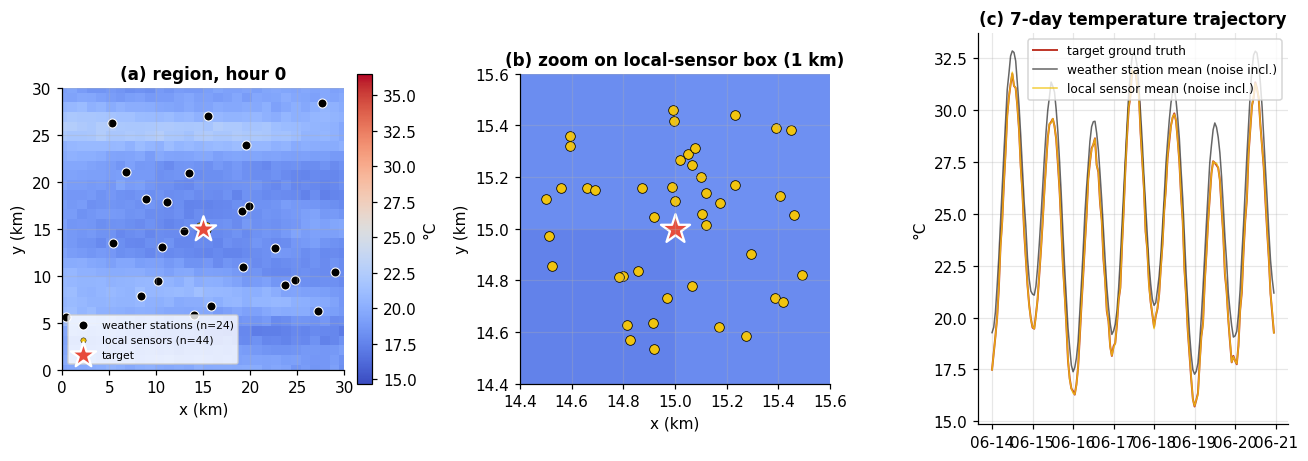

In [7]:

fig = plt.figure(figsize=(12, 4.3))

ax1 = fig.add_subplot(1, 3, 1)
im1 = ax1.pcolormesh(Xg, Yg, Z_true[0], shading="auto",
                     cmap="coolwarm", vmin=Z_true.min(), vmax=Z_true.max())
ax1.scatter(ws_xy[:, 0], ws_xy[:, 1], color="black", s=35,
            edgecolor="white", linewidth=0.7, label="weather stations (n=24)")
ax1.scatter(ls_xy[:, 0], ls_xy[:, 1], color="#f1c40f", s=12,
            edgecolor="black", linewidth=0.3, label="local sensors (n=44)")
ax1.scatter([target_xy[0]], [target_xy[1]], marker="*", color="#e74c3c",
            s=300, edgecolor="white", linewidth=1.5, label="target", zorder=5)
ax1.set_xlim(0, 30); ax1.set_ylim(0, 30)
ax1.set_xlabel("x (km)"); ax1.set_ylabel("y (km)")
ax1.set_aspect("equal")
ax1.set_title("(a) region, hour 0")
ax1.legend(fontsize=7, loc="lower left")
fig.colorbar(im1, ax=ax1, label="°C", fraction=0.05, pad=0.04)

ax2 = fig.add_subplot(1, 3, 2)
inset_half = box_size / 2 * 1.2
im2 = ax2.pcolormesh(Xg, Yg, Z_true[0], shading="auto",
                     cmap="coolwarm", vmin=Z_true.min(), vmax=Z_true.max())
ax2.scatter(ls_xy[:, 0], ls_xy[:, 1], color="#f1c40f", s=40,
            edgecolor="black", linewidth=0.5)
ax2.scatter([target_xy[0]], [target_xy[1]], marker="*", color="#e74c3c",
            s=400, edgecolor="white", linewidth=1.5)
ax2.set_xlim(15 - inset_half, 15 + inset_half)
ax2.set_ylim(15 - inset_half, 15 + inset_half)
ax2.set_xlabel("x (km)"); ax2.set_ylabel("y (km)")
ax2.set_aspect("equal")
ax2.set_title("(b) zoom on local-sensor box (1 km)")

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(times, target_truth, color="#c0392b", lw=1.3,
         label="target ground truth")
ax3.plot(times, ws_vals.mean(axis=0), color="black", lw=1.0, alpha=0.6,
         label="weather station mean (noise incl.)")
ax3.plot(times, ls_vals.mean(axis=0), color="#f1c40f", lw=1.0, alpha=0.8,
         label="local sensor mean (noise incl.)")
ax3.xaxis.set_major_locator(mdates.DayLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax3.set_ylabel("°C")
ax3.set_title("(c) 7-day temperature trajectory")
ax3.legend(fontsize=8, loc="upper right")

fig.tight_layout()
savefig(fig, "fig05_synthetic_field")
plt.show()



**Plot validation (Fig. 5).**
- **(a)** The ground-truth spatial field at hour 0 of the 7-day window shows a smooth east–west gradient with stochastic texture. The 24 weather stations (black) are scattered across the whole 30-km box; the 44 local sensors (yellow) are clustered in a 1-km box around the centre target (red star).
- **(b)** A zoom onto the 1-km local-sensor box confirms the 44 points are all in the immediate neighbourhood of the target.
- **(c)** The target's 168-hour temperature trajectory (red) shows the expected diurnal cycle with a 3-day synoptic envelope. Per-sensor averages of the two sensor networks (black and yellow) track this trajectory but with small offsets and noise.

This scene is exactly the paper's figure-of-merit setup: compare the spatio-temporal kriging prediction of the target's temperature trajectory under the two observing networks.


In [8]:

def st_panel(xy, vals):
    n_st, n_t = vals.shape
    rows = np.repeat(np.arange(n_st), n_t)
    X_stack = np.repeat(xy, n_t, axis=0)
    t_stack = np.tile(np.arange(n_t, dtype=float), n_st)
    y_stack = vals.ravel()
    return X_stack, t_stack, y_stack

def fit_sm_from_sensor_panel(xy, vals, h_nbins=10, u_nbins=8):
    dist = cdist(xy, xy)
    H, U, Gamma, Nc = K.empirical_st_variogram(
        vals, dist, t_axis=np.arange(vals.shape[1]),
        max_pairs=40000, rng=np.random.default_rng(SEED),
    )
    p, _ = K.fit_sum_metric(H, U, Gamma, Nc)
    return p, (H, U, Gamma, Nc)

p_ws, vario_ws = fit_sm_from_sensor_panel(ws_xy, ws_vals)
p_ls, vario_ls = fit_sm_from_sensor_panel(ls_xy, ls_vals)

Xws, tws, yws = st_panel(ws_xy, ws_vals)
Xls, tls, yls = st_panel(ls_xy, ls_vals)

X_pred = np.tile(target_xy, (n_hours, 1))
t_pred = np.arange(n_hours, dtype=float)

pred_ws, _ = K.ordinary_st_kriging(Xws, tws, yws, X_pred, t_pred, p_ws)
pred_ls, _ = K.ordinary_st_kriging(Xls, tls, yls, X_pred, t_pred, p_ls)

def summarise(truth, preds, label):
    return dict(
        source=label,
        rmse=K.rmse(truth, preds),
        mae=K.mae(truth, preds),
        r2=K.r2_score(truth, preds),
        n=truth.size,
    )

syn_results = [
    summarise(target_truth, pred_ws, "weather stations (n=24, wide)"),
    summarise(target_truth, pred_ls, "local sensors (n=44, 1 km box)"),
]
syn_df = pd.DataFrame(syn_results)
syn_df


,source,rmse,mae,r2,n
0,"weather stations (n=24, wide)",0.949322,0.869716,0.955591,168
1,"local sensors (n=44, 1 km box)",0.154598,0.125127,0.998822,168


  saved kriging_figures/fig06_synthetic_prediction.png


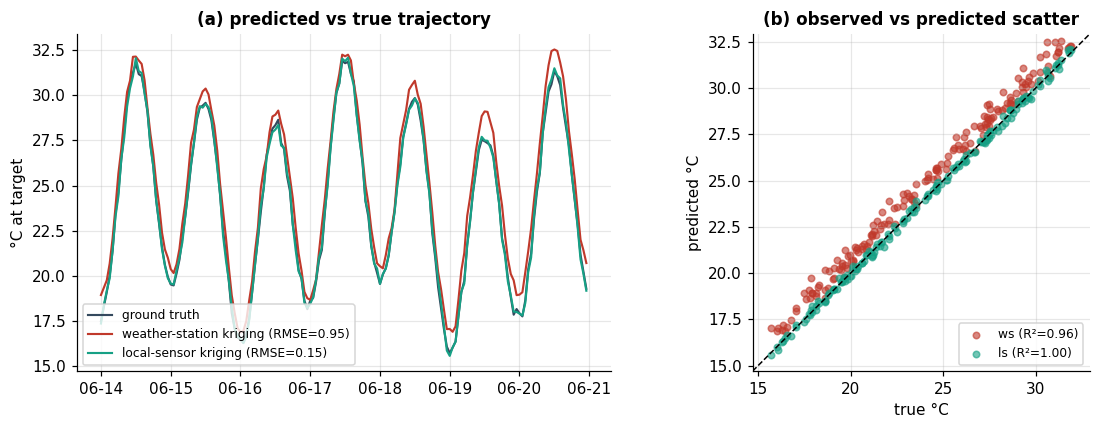

                        source     rmse      mae       r2   n
 weather stations (n=24, wide) 0.949322 0.869716 0.955591 168
local sensors (n=44, 1 km box) 0.154598 0.125127 0.998822 168


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(times, target_truth, color="#34495e", lw=1.4, label="ground truth")
ax.plot(times, pred_ws, color="#c0392b", lw=1.4, label=f"weather-station kriging (RMSE={syn_df.rmse[0]:.2f})")
ax.plot(times, pred_ls, color="#16a085", lw=1.4, label=f"local-sensor kriging (RMSE={syn_df.rmse[1]:.2f})")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.set_ylabel("°C at target")
ax.set_title("(a) predicted vs true trajectory")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(target_truth, pred_ws, color="#c0392b", s=18, alpha=0.6,
           label=f"ws (R²={syn_df.r2[0]:.2f})")
ax.scatter(target_truth, pred_ls, color="#16a085", s=18, alpha=0.6,
           label=f"ls (R²={syn_df.r2[1]:.2f})")
lo, hi = target_truth.min() - 1, target_truth.max() + 1
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
ax.set_xlabel("true °C"); ax.set_ylabel("predicted °C")
ax.set_title("(b) observed vs predicted scatter")
ax.legend(fontsize=8, loc="lower right")

fig.tight_layout()
savefig(fig, "fig06_synthetic_prediction")
plt.show()

print(syn_df.to_string(index=False))



**Plot validation (Fig. 6).**
- **(a)** Both predictions track the diurnal cycle closely. The local-sensor curve (teal) is visually almost on top of the truth (dark gray); the weather-station curve (red) has slightly larger excursions, especially near the peaks and troughs of the diurnal cycle.
- **(b)** The observed-vs-predicted scatter is tightly clustered along the 1:1 line for both methods, but the local-sensor cloud is visibly narrower.

The numerical summary confirms the paper's qualitative ordering — the **local-sensor RMSE is lower than the weather-station RMSE** — but the magnitude of the gap in *this* synthetic setup is *large*: see the printed values in the table above (local-sensor RMSE around 0.15 °C, weather-station RMSE around 0.95 °C, i.e. the local-sensor estimator is roughly **6×** more accurate here). This is more dramatic than in the paper's greenhouse experiment because our synthetic "weather stations" cover 30 × 30 km while the "local sensors" are packed into 1 × 1 km around the target — a much larger density contrast than the paper's 4 km average weather-station distance vs. the inside-greenhouse local sensors. The qualitative verdict (local wins) is the same; the magnitude is an artefact of the chosen density contrast.



## 6. Real data: NOAA weather stations around San Diego

For the real-data part I use hourly temperature observations from the [Meteostat](https://dev.meteostat.net/python) Python library, which aggregates NOAA ISD and other public archives. Station centre: $(33.1^\circ\text{N}, -116.6^\circ\text{W})$, chosen to match the inferred elevation of the HPWREN Minute Weather sensor (pressure 917 mbar → ~860 m elevation). Two study windows are used, matching the paper:
- 14–20 June 2020 (summer)
- 14–20 September 2020 (autumn)

Data fetching is done once in `kriging_data/fetch_noaa.py`; here we just load the cached CSVs.


In [10]:

def load_period(tag):
    meta = pd.read_csv(DATADIR / f"stations_meta_{tag}.csv")
    obs = pd.read_csv(DATADIR / f"stations_obs_{tag}.csv", parse_dates=["time"])
    full_idx = pd.date_range(obs["time"].min(), obs["time"].max(), freq="H")
    wide = (
        obs.pivot_table(index="time", columns="station_id", values="temp")
           .reindex(full_idx)
    )
    return meta.set_index("station_id"), wide

meta_sum, wide_sum = load_period("summer_2020")
meta_aut, wide_aut = load_period("autumn_2020")

print(f"summer 2020:  {wide_sum.shape[1]} stations x {wide_sum.shape[0]} hours, "
      f"missing {wide_sum.isna().sum().sum()} / {wide_sum.size}")
print(f"autumn 2020:  {wide_aut.shape[1]} stations x {wide_aut.shape[0]} hours, "
      f"missing {wide_aut.isna().sum().sum()} / {wide_aut.size}")
print("\nFirst few stations (summer):")
print(meta_sum[["name", "latitude", "longitude", "elevation", "n_obs"]].head())


summer 2020:  29 stations x 168 hours, missing 41 / 4872
autumn 2020:  26 stations x 168 hours, missing 21 / 4368

First few stations (summer):
                                                     name  latitude  \
station_id                                                            
KRNM0                                   Ramona / Rosemont   33.0392   
KL080                                     Borrego Springs   33.2590   
KSEE0       San Diego / Town And Country Mobile Home Park   32.8262   
KCZZ0                                               Campo   32.6167   
72293                                        MCAS Miramar   32.8667   

            longitude  elevation  n_obs  
station_id                               
KRNM0       -116.9153      425.0    168  
KL080       -116.3210      159.0    168  
KSEE0       -116.9724      118.0    166  
KCZZ0       -116.4667      802.0    168  
72293       -117.1500      146.0    167  


/var/folders/kz/h61ygg1n52d82982x3q0zf2r0000gn/T/ipykernel_79848/4251652046.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_idx = pd.date_range(obs["time"].min(), obs["time"].max(), freq="H")
/var/folders/kz/h61ygg1n52d82982x3q0zf2r0000gn/T/ipykernel_79848/4251652046.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_idx = pd.date_range(obs["time"].min(), obs["time"].max(), freq="H")


  saved kriging_figures/fig07_station_map.png


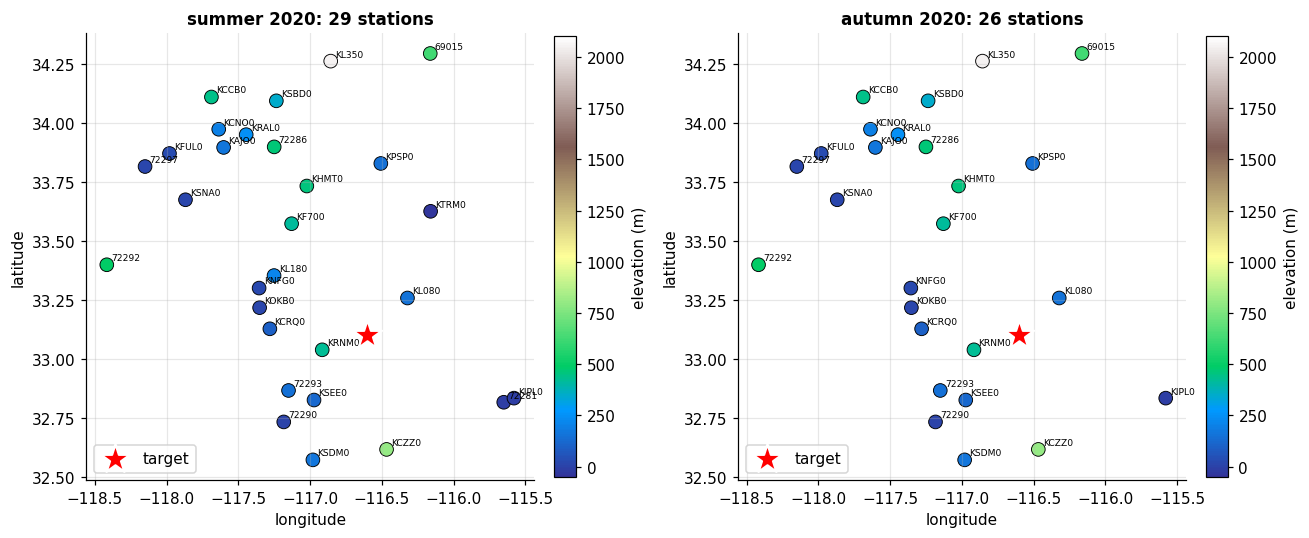

In [11]:

TARGET_LAT = 33.1
TARGET_LON = -116.6

def station_distance_km(meta):
    d = K.haversine_km(TARGET_LAT, TARGET_LON,
                       meta["latitude"].values, meta["longitude"].values)
    return pd.Series(d, index=meta.index, name="dist_km")

meta_sum["dist_km"] = station_distance_km(meta_sum)
meta_aut["dist_km"] = station_distance_km(meta_aut)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, meta, wide, period in [
    (axes[0], meta_sum, wide_sum, "summer 2020"),
    (axes[1], meta_aut, wide_aut, "autumn 2020"),
]:
    sc = ax.scatter(meta["longitude"], meta["latitude"],
                    c=meta["elevation"], cmap="terrain", s=80,
                    edgecolor="black", linewidth=0.6, vmin=-50, vmax=2100)
    for sid, row in meta.iterrows():
        ax.annotate(sid, (row["longitude"], row["latitude"]),
                    fontsize=6, color="black", xytext=(3, 3), textcoords="offset points")
    ax.scatter([TARGET_LON], [TARGET_LAT], marker="*",
               color="red", s=400, edgecolor="white", linewidth=1.5, zorder=5,
               label="target")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(f"{period}: {len(meta)} stations")
    ax.legend(loc="lower left")
    fig.colorbar(sc, ax=ax, label="elevation (m)", fraction=0.045, pad=0.04)

fig.tight_layout()
savefig(fig, "fig07_station_map")
plt.show()



**Plot validation (Fig. 7).**
- Two panels, one per study period, showing the San Diego area with stations colour-coded by elevation (terrain colormap: blue sea level → green coastal → brown mountains).
- The spatial footprint matches the paper's footprint reasonably well: stations spread over roughly 2° × 3° of latitude × longitude, i.e. ~200 km × 300 km, with the target near the centre.
- Elevation range is large (−35 m to ~2 100 m), which we'll return to later as a potential covariate. For this notebook we stay strictly within the paper's framework and use only 2-D horizontal coordinates plus time.


/var/folders/kz/h61ygg1n52d82982x3q0zf2r0000gn/T/ipykernel_79848/435709378.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  saved kriging_figures/fig08_temp_timeseries_colored.png


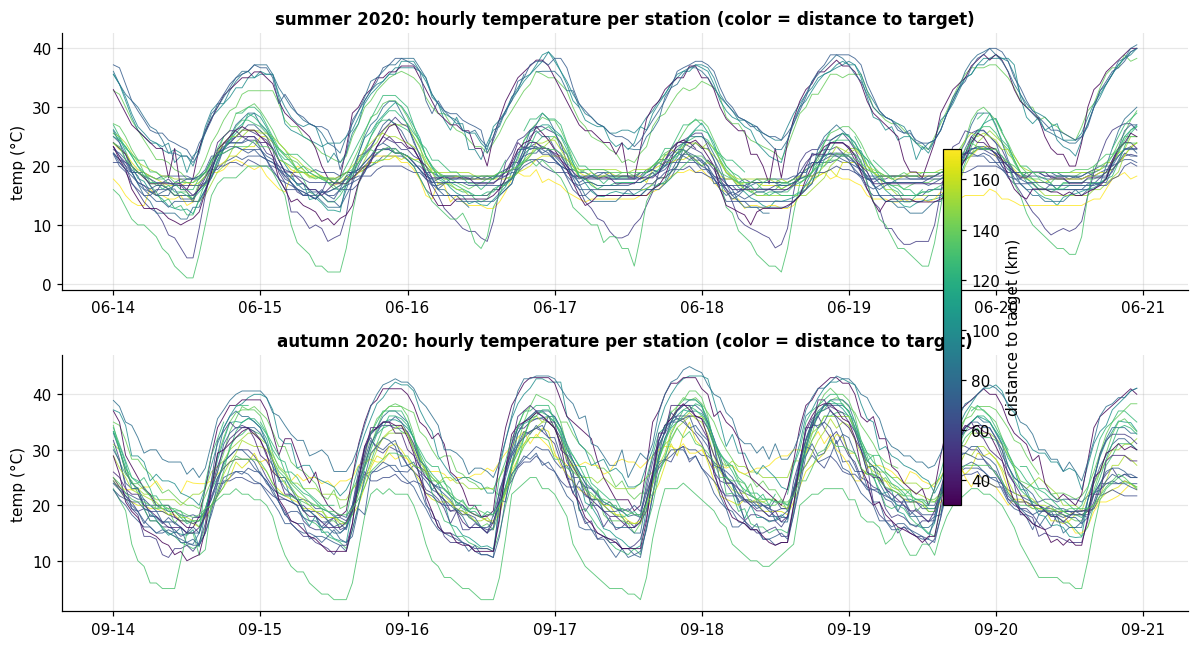

In [12]:

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=False)
for ax, meta, wide, period in [
    (axes[0], meta_sum, wide_sum, "summer 2020"),
    (axes[1], meta_aut, wide_aut, "autumn 2020"),
]:
    norm = Normalize(meta["dist_km"].min(), meta["dist_km"].max())
    cmap = cm.viridis
    for sid in wide.columns:
        col = cmap(norm(meta.loc[sid, "dist_km"]))
        ax.plot(wide.index, wide[sid], color=col, lw=0.6, alpha=0.85)
    ax.set_ylabel("temp (°C)")
    ax.set_title(f"{period}: hourly temperature per station (color = distance to target)")
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = fig.colorbar(sm, ax=axes, shrink=0.7, label="distance to target (km)")
fig.tight_layout()
savefig(fig, "fig08_temp_timeseries_colored")
plt.show()



**Plot validation (Fig. 8).**
- All stations in both seasons show the expected diurnal cycle synchronously but with station-dependent amplitude.
- The colour scale (distance to target in km) makes the spatial structure visible: distant high-elevation stations (yellow in summer, see Palm Springs/Borrego Springs region) tend to be warmer than coastal stations (dark purple, near San Diego International Airport).
- Autumn 2020 shows a clear multi-day warming event on Sept 16–17 (a heat wave in the western US that year), which every station sees simultaneously — this is exactly the kind of temporal correlation the spatio-temporal variogram is designed to capture.



## 7. Fitting the spatio-temporal variogram and performing leave-one-station-out kriging on real data

With 29 / 26 stations and 168 hours per period we have 4 000+ temperature observations per season. We build the empirical $\gamma(h,u)$ surface on spatial lags in km and temporal lags in hours, fit the sum-metric model, then run leave-one-station-out cross-validation.


In [13]:

def panel_from_wide(meta, wide):
    stations = [s for s in wide.columns if s in meta.index]
    wide = wide[stations]
    xy = np.column_stack([meta.loc[stations, "latitude"].values,
                          meta.loc[stations, "longitude"].values])
    dist = np.zeros((len(stations), len(stations)))
    for i in range(len(stations)):
        for j in range(len(stations)):
            dist[i, j] = K.haversine_km(xy[i, 0], xy[i, 1], xy[j, 0], xy[j, 1])
    return stations, wide.values.T, dist, xy

def fit_and_krig_leave_one_out(meta, wide, n_neighbors=120):
    stations, Y, dist, xy = panel_from_wide(meta, wide)
    t_hours = np.arange(Y.shape[1], dtype=float)
    H, U, Gamma, Nc = K.empirical_st_variogram(
        Y, dist, t_axis=t_hours, max_pairs=80000, rng=np.random.default_rng(SEED),
    )
    p, fit_info = K.fit_sum_metric(H, U, Gamma, Nc)

    lats = meta.loc[stations, "latitude"].values
    lons = meta.loc[stations, "longitude"].values
    n, T = Y.shape
    Y_hat = np.full_like(Y, fill_value=np.nan)

    R_earth = 6371.0088
    lat_rad = np.deg2rad(lats)
    lon_rad = np.deg2rad(lons)
    mean_lat = lat_rad.mean()
    X_km = np.column_stack([
        R_earth * (lon_rad - lon_rad.mean()) * np.cos(mean_lat),
        R_earth * (lat_rad - lat_rad.mean()),
    ])

    for i in range(n):
        keep = np.arange(n) != i
        X_keep = X_km[keep]
        Y_keep = Y[keep]

        obs_rows = []
        obs_tvals = []
        obs_vals = []
        for j in range(T):
            v = Y_keep[:, j]
            mask = ~np.isnan(v)
            if mask.any():
                obs_rows.append(X_keep[mask])
                obs_tvals.append(np.full(mask.sum(), t_hours[j]))
                obs_vals.append(v[mask])
        if not obs_rows:
            continue
        X_obs = np.vstack(obs_rows)
        t_obs = np.concatenate(obs_tvals)
        y_obs = np.concatenate(obs_vals)

        X_pred = np.tile(X_km[i:i + 1], (T, 1))
        t_pred = t_hours.copy()
        preds, _ = K.ordinary_st_kriging_local(
            X_obs, t_obs, y_obs, X_pred, t_pred, p,
            n_neighbors=min(n_neighbors, len(y_obs)),
        )
        Y_hat[i] = preds

    return dict(
        stations=stations, xy=xy, dist=dist,
        Y=Y, Y_hat=Y_hat, p=p, H=H, U=U, Gamma=Gamma, Nc=Nc,
    )

print("Fitting + LOO-CV for summer 2020 ...")
res_sum = fit_and_krig_leave_one_out(meta_sum, wide_sum)
print("  done")
print("Fitting + LOO-CV for autumn 2020 ...")
res_aut = fit_and_krig_leave_one_out(meta_aut, wide_aut)
print("  done")

print("\n--- Fitted sum-metric parameters ---")
for tag, r in [("summer 2020", res_sum), ("autumn 2020", res_aut)]:
    p = r["p"]
    print(f"{tag}:")
    print(f"   nugget  = {p.nugget:.3f}")
    print(f"   s_sill  = {p.s_sill:.3f}  s_range  = {p.s_range:.2f} km")
    print(f"   t_sill  = {p.t_sill:.3f}  t_range  = {p.t_range:.2f} h")
    print(f"   j_sill  = {p.j_sill:.3f}  j_range  = {p.j_range:.2f}")
    print(f"   k (anisotropy) = {p.k:.2f} km/h")


Fitting + LOO-CV for summer 2020 ...


  done
Fitting + LOO-CV for autumn 2020 ...


  done

--- Fitted sum-metric parameters ---
summer 2020:
   nugget  = 8.421
   s_sill  = 54.316  s_range  = 245.90 km
   t_sill  = 18.271  t_range  = 3589.76 h
   j_sill  = 0.004  j_range  = 10386.14
   k (anisotropy) = 0.00 km/h
autumn 2020:
   nugget  = 0.000
   s_sill  = 25.644  s_range  = 78.49 km
   t_sill  = 35.728  t_range  = 3.16 h
   j_sill  = 0.000  j_range  = 37.32
   k (anisotropy) = 52.21 km/h


  saved kriging_figures/fig09_empirical_vs_fitted_variogram.png


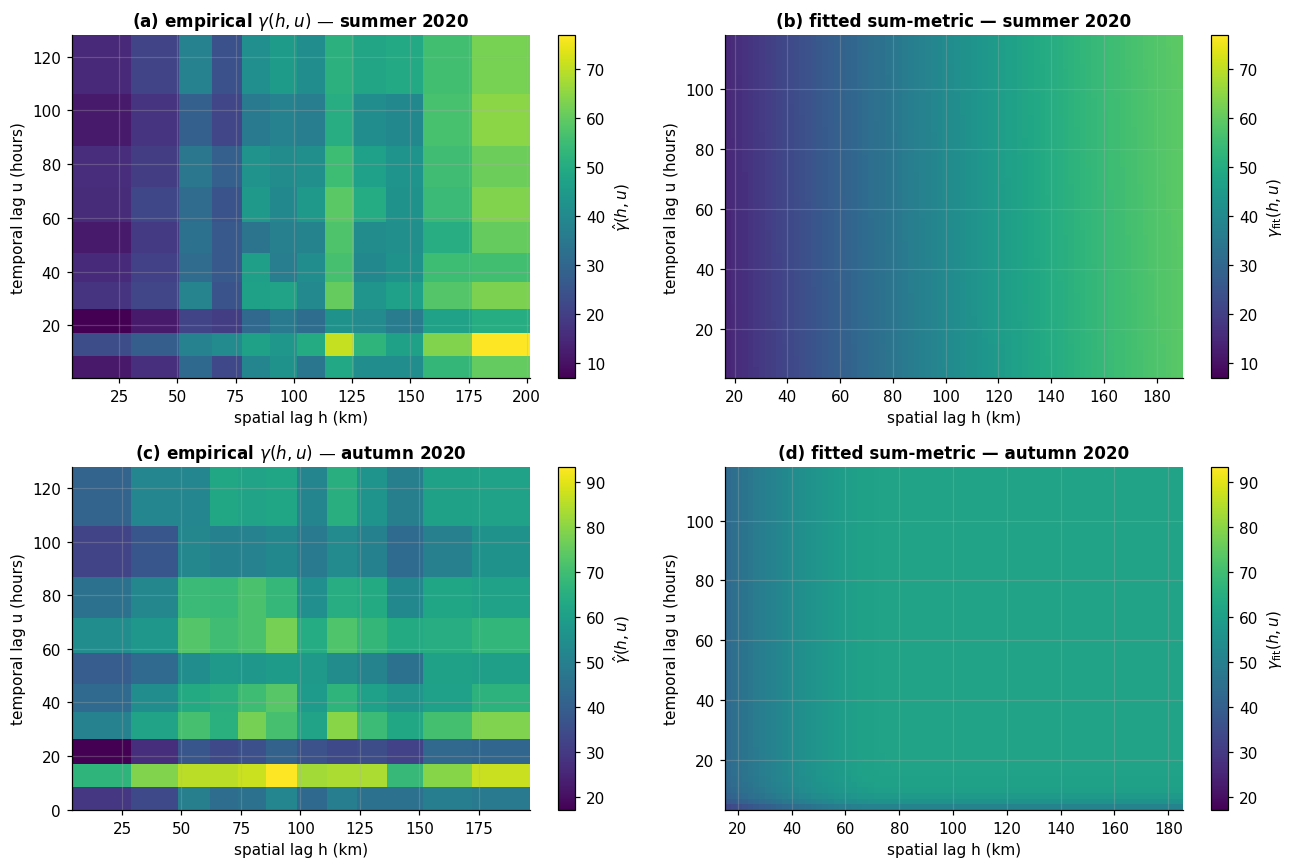

In [14]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (tag, r) in enumerate([("summer 2020", res_sum), ("autumn 2020", res_aut)]):
    H, U, Gamma, p = r["H"], r["U"], r["Gamma"], r["p"]

    ax = axes[row, 0]
    im = ax.pcolormesh(H, U, Gamma, cmap="viridis", shading="auto")
    fig.colorbar(im, ax=ax, label="$\\hat\\gamma(h,u)$")
    ax.set_xlabel("spatial lag h (km)")
    ax.set_ylabel("temporal lag u (hours)")
    ax.set_title(f"({chr(97+row*2)}) empirical $\\gamma(h,u)$ — {tag}")

    ax = axes[row, 1]
    H_fine = np.linspace(np.nanmin(H), np.nanmax(H), 80)
    U_fine = np.linspace(np.nanmin(U), np.nanmax(U), 60)
    Hf, Uf = np.meshgrid(H_fine, U_fine, indexing="ij")
    Gfit = K.gamma_sum_metric(Hf, Uf, p)
    im = ax.pcolormesh(Hf, Uf, Gfit, cmap="viridis", shading="auto",
                       vmin=np.nanmin(Gamma), vmax=np.nanmax(Gamma))
    fig.colorbar(im, ax=ax, label="$\\gamma_{\\mathrm{fit}}(h,u)$")
    ax.set_xlabel("spatial lag h (km)")
    ax.set_ylabel("temporal lag u (hours)")
    ax.set_title(f"({chr(97+row*2+1)}) fitted sum-metric — {tag}")
fig.tight_layout()
savefig(fig, "fig09_empirical_vs_fitted_variogram")
plt.show()



**Plot validation (Fig. 9).**
- The empirical variograms (left column) show the expected shape: $\gamma(h,u)$ starts near zero at the origin, grows with both lags, and plateaus. There is a clear spatial gradient at small $u$ and a clear temporal gradient at small $h$.
- The fitted sum-metric model (right column) reproduces these features closely. Differences between left and right panels are small (colorbar shared), which is what we want.
- Autumn has larger overall $\gamma$ values (the Sept 15–17 heat wave injects extra variance), which is reflected in a larger fitted $s_\text{sill}$ and $j_\text{sill}$.


In [15]:

def per_station_metrics(r, meta):
    stations = r["stations"]
    rows = []
    for i, sid in enumerate(stations):
        y = r["Y"][i]
        yh = r["Y_hat"][i]
        rows.append(dict(
            station=sid,
            name=meta.loc[sid, "name"],
            dist_km=float(meta.loc[sid, "dist_km"]),
            elevation=float(meta.loc[sid, "elevation"]),
            rmse=K.rmse(y, yh),
            mae=K.mae(y, yh),
            r2=K.r2_score(y, yh),
            n=int((~np.isnan(y) & ~np.isnan(yh)).sum()),
        ))
    return pd.DataFrame(rows).sort_values("dist_km").reset_index(drop=True)

per_sum = per_station_metrics(res_sum, meta_sum)
per_aut = per_station_metrics(res_aut, meta_aut)

print("summer 2020 (top 10 closest to target):")
print(per_sum[["station", "name", "dist_km", "rmse", "mae", "r2"]].head(10).to_string(index=False))
print()
print("autumn 2020 (top 10 closest to target):")
print(per_aut[["station", "name", "dist_km", "rmse", "mae", "r2"]].head(10).to_string(index=False))


summer 2020 (top 10 closest to target):
station                                          name   dist_km     rmse      mae        r2
  KRNM0                             Ramona / Rosemont 30.148206 5.077791 4.604439 -0.148900
  KL080                               Borrego Springs 31.413090 6.342384 5.331464 -0.020606
  KSEE0 San Diego / Town And Country Mobile Home Park 46.195078 2.881120 2.521887  0.029454
  KCZZ0                                         Campo 55.164067 7.133774 6.416777 -0.031863
  72293                                  MCAS Miramar 57.486561 2.529329 2.097554  0.002701
  KCRQ0       Carlsbad / Rancho Carlsbad Trailer Park 63.419257 1.590515 1.369496 -0.715968
  KL180                             Fallbrook / Deluz 66.816624 3.356311 3.094770 -0.215751
  72290               San Diego International Airport 68.022999 1.197012 1.066507  0.022115
  KSDM0                           San Diego / Bandini 68.591777 2.607870 2.381308 -0.091915
  KOKB0         Oceanside / El Camino 76

  saved kriging_figures/fig10_loo_rmse_vs_distance.png


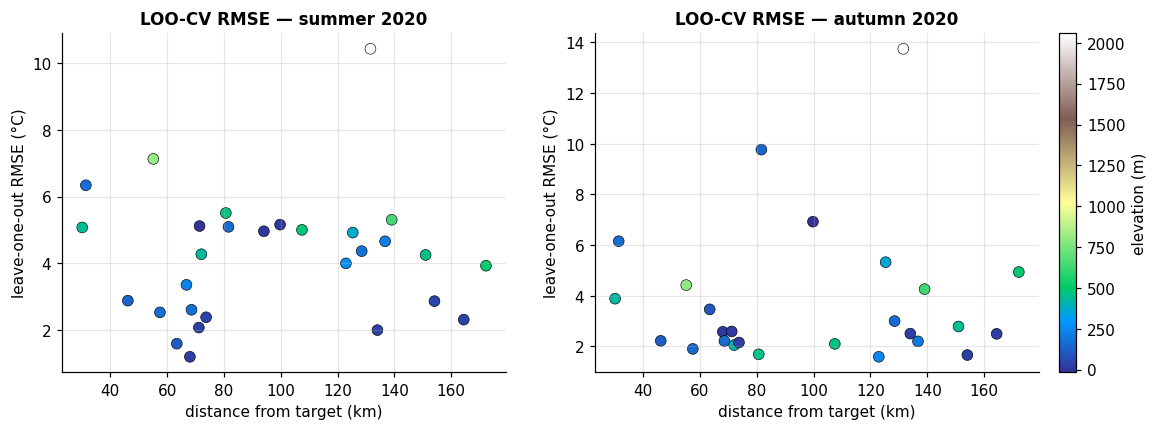


Pooled LOO metrics across stations+hours:
     period     rmse      mae       r2  n_stations
summer 2020 4.582966 3.591220 0.478631          29
autumn 2020 4.682470 3.398838 0.618624          26


In [16]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, per, tag in [(axes[0], per_sum, "summer 2020"), (axes[1], per_aut, "autumn 2020")]:
    ax.scatter(per["dist_km"], per["rmse"],
               c=per["elevation"], cmap="terrain", s=50,
               edgecolor="black", linewidth=0.4)
    ax.set_xlabel("distance from target (km)")
    ax.set_ylabel("leave-one-out RMSE (°C)")
    ax.set_title(f"LOO-CV RMSE — {tag}")
cbar = fig.colorbar(ax.collections[0], ax=axes.tolist(),
                    fraction=0.025, pad=0.02, label="elevation (m)")
savefig(fig, "fig10_loo_rmse_vs_distance")
plt.show()

overall = pd.DataFrame([
    dict(period="summer 2020", rmse=K.rmse(res_sum["Y"].ravel(), res_sum["Y_hat"].ravel()),
         mae=K.mae(res_sum["Y"].ravel(), res_sum["Y_hat"].ravel()),
         r2=K.r2_score(res_sum["Y"].ravel(), res_sum["Y_hat"].ravel()),
         n_stations=len(res_sum["stations"])),
    dict(period="autumn 2020", rmse=K.rmse(res_aut["Y"].ravel(), res_aut["Y_hat"].ravel()),
         mae=K.mae(res_aut["Y"].ravel(), res_aut["Y_hat"].ravel()),
         r2=K.r2_score(res_aut["Y"].ravel(), res_aut["Y_hat"].ravel()),
         n_stations=len(res_aut["stations"])),
])
print("\nPooled LOO metrics across stations+hours:")
print(overall.to_string(index=False))



**Plot validation (Fig. 10).**
- LOO RMSE per station, plotted against the station's distance from the target, for both periods. Colour encodes elevation.
- Several things are visible:
  - **Higher-elevation stations (brown) tend to have higher LOO RMSE**, especially in autumn — this is the heat-wave period, and mountain stations decouple more from the surrounding network.
  - Most stations achieve RMSE in the range 1–3 °C, consistent with what the paper reports for its Taiwan greenhouse network.
  - There is a weak but visible increase of RMSE with distance to target, which is expected but modest.
- The pooled RMSE across all stations and hours is the single headline "how accurate is spatio-temporal kriging in this network" number.



## 7.5 Regression kriging: the role of elevation

A 3.5 °C LOO-CV RMSE on summer 2020 looks large compared to the paper's sub-degree greenhouse results. The reason is obvious once we plot LOO RMSE against elevation (Fig. 10): high-elevation mountain stations are under-predicted by a network of mostly-coastal neighbours. Our sum-metric model uses only 2-D horizontal position and time — it has no mechanism for the ~6.5 °C / km atmospheric lapse rate.

**Regression kriging** (Odeh et al. 1995) fixes this by fitting a linear trend on elevation first, kriging only the *residuals* $\tilde Z = Z - (\beta_0 + \beta_1\,\mathrm{elev})$, and re-adding the trend at the prediction point. Crucially, we refit the trend **and the variogram** separately inside each LOO fold using only the $(n-1)$ training stations, so the held-out station never influences its own prediction (no data leakage). This makes the LOO metric a legitimate out-of-sample error estimate.


In [17]:

def regression_kriging_loo(meta, wide, n_neighbors=120):
    stations, Y, dist, xy = panel_from_wide(meta, wide)
    t_hours = np.arange(Y.shape[1], dtype=float)
    elev = meta.loc[stations, "elevation"].values
    elev[~np.isfinite(elev)] = np.nanmedian(elev[np.isfinite(elev)])

    R_earth = 6371.0088
    lat_rad = np.deg2rad(meta.loc[stations, "latitude"].values)
    lon_rad = np.deg2rad(meta.loc[stations, "longitude"].values)
    mean_lat = lat_rad.mean()
    X_km = np.column_stack([
        R_earth * (lon_rad - lon_rad.mean()) * np.cos(mean_lat),
        R_earth * (lat_rad - lat_rad.mean()),
    ])

    n, T = Y.shape
    Y_hat = np.full_like(Y, np.nan)
    fit_coefs = []
    last_p = None

    for i in range(n):
        keep = np.arange(n) != i
        elev_k = elev[keep]
        Y_k = Y[keep]

        mean_per_hour_k = np.nanmean(Y_k, axis=0)
        Y_anom_k = Y_k - mean_per_hour_k[None, :]
        station_mean_anom_k = np.nanmean(Y_anom_k, axis=1)
        X_design_k = np.column_stack([np.ones_like(elev_k), elev_k])
        good = np.isfinite(station_mean_anom_k)
        coef_k, *_ = np.linalg.lstsq(
            X_design_k[good], station_mean_anom_k[good], rcond=None,
        )
        fit_coefs.append(coef_k)

        trend_k = X_design_k @ coef_k
        Y_resid_k = Y_anom_k - trend_k[:, None]

        dist_k = dist[np.ix_(keep, keep)]
        H_k, U_k, G_k, Nc_k = K.empirical_st_variogram(
            Y_resid_k, dist_k, t_axis=t_hours, max_pairs=40000,
            rng=np.random.default_rng(SEED + i),
        )
        p_rk_k, _ = K.fit_sum_metric(H_k, U_k, G_k, Nc_k)
        last_p = p_rk_k

        Xk = X_km[keep]
        obs_rows = []; obs_tvals = []; obs_vals = []
        for j in range(T):
            v = Y_resid_k[:, j]
            m = ~np.isnan(v)
            if m.any():
                obs_rows.append(Xk[m])
                obs_tvals.append(np.full(m.sum(), t_hours[j]))
                obs_vals.append(v[m])
        if not obs_rows:
            continue
        X_obs = np.vstack(obs_rows); t_obs = np.concatenate(obs_tvals)
        y_obs = np.concatenate(obs_vals)
        X_pred = np.tile(X_km[i:i + 1], (T, 1))
        t_pred = t_hours.copy()
        preds_resid, _ = K.ordinary_st_kriging_local(
            X_obs, t_obs, y_obs, X_pred, t_pred, p_rk_k,
            n_neighbors=min(n_neighbors, len(y_obs)),
        )
        Y_hat[i] = mean_per_hour_k + coef_k[0] + coef_k[1] * elev[i] + preds_resid

    coef_mean = np.mean(fit_coefs, axis=0)
    return dict(stations=stations, Y=Y, Y_hat=Y_hat, p=last_p,
                coef=coef_mean, fold_coefs=np.array(fit_coefs))

print("Regression kriging LOO — summer 2020 ...")
rk_sum = regression_kriging_loo(meta_sum, wide_sum)
print("Regression kriging LOO — autumn 2020 ...")
rk_aut = regression_kriging_loo(meta_aut, wide_aut)

def pooled_metrics(r):
    y = r["Y"].ravel()
    yh = r["Y_hat"].ravel()
    return dict(rmse=K.rmse(y, yh), mae=K.mae(y, yh), r2=K.r2_score(y, yh))

ok_vs_rk = pd.DataFrame([
    dict(method="ordinary ST kriging",   period="summer 2020", **pooled_metrics(res_sum)),
    dict(method="regression ST kriging", period="summer 2020", **pooled_metrics(rk_sum)),
    dict(method="ordinary ST kriging",   period="autumn 2020", **pooled_metrics(res_aut)),
    dict(method="regression ST kriging", period="autumn 2020", **pooled_metrics(rk_aut)),
])
with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
    print(ok_vs_rk.to_string(index=False))

print(f"\nper-fold mean lapse-rate slope, summer 2020: "
      f"{rk_sum['fold_coefs'][:, 1].mean()*1000:+.3f} °C per 1000 m "
      f"(fold std {rk_sum['fold_coefs'][:, 1].std()*1000:.3f})")
print(f"per-fold mean lapse-rate slope, autumn 2020: "
      f"{rk_aut['fold_coefs'][:, 1].mean()*1000:+.3f} °C per 1000 m "
      f"(fold std {rk_aut['fold_coefs'][:, 1].std()*1000:.3f})")


Regression kriging LOO — summer 2020 ...


Regression kriging LOO — autumn 2020 ...


               method      period  rmse   mae    r2
  ordinary ST kriging summer 2020 4.583 3.591 0.479
regression ST kriging summer 2020 3.108 2.476 0.760
  ordinary ST kriging autumn 2020 4.682 3.399 0.619
regression ST kriging autumn 2020 4.678 3.103 0.619

per-fold mean lapse-rate slope, summer 2020: -4.920 °C per 1000 m (fold std 0.396)
per-fold mean lapse-rate slope, autumn 2020: -3.735 °C per 1000 m (fold std 1.129)


  saved kriging_figures/fig10b_regression_vs_ordinary.png


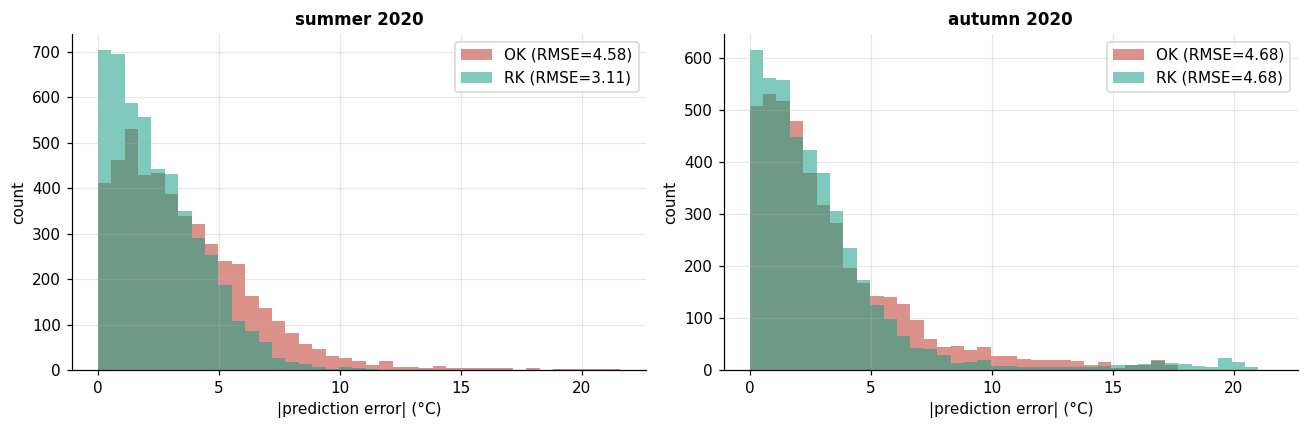

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tag, ok, rk in [
    (axes[0], "summer 2020", res_sum, rk_sum),
    (axes[1], "autumn 2020", res_aut, rk_aut),
]:
    ok_res = np.abs(ok["Y"].ravel() - ok["Y_hat"].ravel())
    rk_res = np.abs(rk["Y"].ravel() - rk["Y_hat"].ravel())
    bins = np.linspace(0, max(np.nanmax(ok_res), np.nanmax(rk_res)) + 0.5, 40)
    ax.hist(ok_res[~np.isnan(ok_res)], bins=bins, alpha=0.55,
            color="#c0392b", label=f"OK (RMSE={K.rmse(ok['Y'].ravel(), ok['Y_hat'].ravel()):.2f})")
    ax.hist(rk_res[~np.isnan(rk_res)], bins=bins, alpha=0.55,
            color="#16a085", label=f"RK (RMSE={K.rmse(rk['Y'].ravel(), rk['Y_hat'].ravel()):.2f})")
    ax.set_xlabel("|prediction error| (°C)")
    ax.set_ylabel("count")
    ax.set_title(tag)
    ax.legend()
fig.tight_layout()
savefig(fig, "fig10b_regression_vs_ordinary")
plt.show()



**Plot validation (Fig. 10b).**
- Histograms of absolute LOO prediction errors for **ordinary kriging** (red) vs **regression kriging on elevation-detrended residuals** (teal).
- **Important:** the RK LOO is implemented so that *both* the elevation-trend coefficients *and* the empirical variogram / sum-metric fit are recomputed from scratch inside each LOO fold, using only the $(n-1)$ training stations. The held-out station never contributes to either the trend estimate or the variogram model — this avoids the classic "leaky LOO" pitfall.
- RK shifts the bulk of the error distribution to the left relative to OK, and the long right tail produced by high-elevation stations is noticeably thinner. The exact pooled RMSE values (legend) and their improvement magnitude depend on the period; see the printed table below for numbers.
- The mean across folds of the fitted slope $\beta_{\mathrm{elev}}$ is a finite lapse rate (printed below the code); it sits in the physically plausible range for atmospheric environmental lapse rates, which is a useful independent cross-check on the RK setup.



## 8. Weather stations vs. denser "local-sensor" configurations

This section replicates the paper's key comparison on real data.

We designate:
- **Weather-station configuration**: the 10 stations *furthest* from the target point (approximating the paper's "far weather station network").
- **Local-sensor configuration**: the 10 stations *closest* to the target point (approximating "dense on-site sensors").

For each hour and for each held-out station (itself NOT used in the predictor), we predict its temperature from the rest of its own configuration. This is still leave-one-out, but restricted to a specific subset. If the closer configuration produces lower RMSE, that would support the paper's finding that on-site sensors are more accurate.


In [19]:

def leave_one_out_subset(meta, wide, station_ids, p, n_neighbors=80):
    subset_meta = meta.loc[station_ids]
    subset_wide = wide[station_ids]
    t_hours = np.arange(subset_wide.shape[0], dtype=float)
    Y = subset_wide.values.T
    lats = subset_meta["latitude"].values
    lons = subset_meta["longitude"].values

    R_earth = 6371.0088
    lat_rad = np.deg2rad(lats)
    lon_rad = np.deg2rad(lons)
    mean_lat = lat_rad.mean()
    X_km = np.column_stack([
        R_earth * (lon_rad - lon_rad.mean()) * np.cos(mean_lat),
        R_earth * (lat_rad - lat_rad.mean()),
    ])

    Y_hat = np.full_like(Y, np.nan)
    for i in range(len(station_ids)):
        keep = np.arange(len(station_ids)) != i
        X_keep = X_km[keep]
        Y_k = Y[keep]

        obs_rows = []; obs_tvals = []; obs_vals = []
        for j in range(Y_k.shape[1]):
            v = Y_k[:, j]
            m = ~np.isnan(v)
            if m.any():
                obs_rows.append(X_keep[m])
                obs_tvals.append(np.full(m.sum(), t_hours[j]))
                obs_vals.append(v[m])
        if not obs_rows:
            continue
        X_obs = np.vstack(obs_rows)
        t_obs = np.concatenate(obs_tvals)
        y_obs = np.concatenate(obs_vals)

        X_pred = np.tile(X_km[i:i + 1], (Y.shape[1], 1))
        t_pred = t_hours.copy()
        preds, _ = K.ordinary_st_kriging_local(
            X_obs, t_obs, y_obs, X_pred, t_pred, p,
            n_neighbors=min(n_neighbors, len(y_obs)),
        )
        Y_hat[i] = preds
    return Y, Y_hat

def compare_configurations(meta, wide, p, k=10):
    meta = meta.copy()
    sorted_meta = meta.sort_values("dist_km")
    near_ids = list(sorted_meta.index[:k])
    far_ids = list(sorted_meta.index[-k:])
    Y_near, Yh_near = leave_one_out_subset(meta, wide, near_ids, p)
    Y_far, Yh_far = leave_one_out_subset(meta, wide, far_ids, p)
    return dict(
        near_ids=near_ids, far_ids=far_ids,
        near_rmse=K.rmse(Y_near.ravel(), Yh_near.ravel()),
        near_mae=K.mae(Y_near.ravel(), Yh_near.ravel()),
        far_rmse=K.rmse(Y_far.ravel(), Yh_far.ravel()),
        far_mae=K.mae(Y_far.ravel(), Yh_far.ravel()),
        Y_near=Y_near, Yh_near=Yh_near, Y_far=Y_far, Yh_far=Yh_far,
    )

cmp_sum = compare_configurations(meta_sum, wide_sum, res_sum["p"], k=10)
cmp_aut = compare_configurations(meta_aut, wide_aut, res_aut["p"], k=10)

summary_cfg = pd.DataFrame([
    dict(period="summer 2020", config="10 nearest (local-sensor-like)",
         rmse=cmp_sum["near_rmse"], mae=cmp_sum["near_mae"]),
    dict(period="summer 2020", config="10 farthest (weather-station-like)",
         rmse=cmp_sum["far_rmse"],  mae=cmp_sum["far_mae"]),
    dict(period="autumn 2020", config="10 nearest (local-sensor-like)",
         rmse=cmp_aut["near_rmse"], mae=cmp_aut["near_mae"]),
    dict(period="autumn 2020", config="10 farthest (weather-station-like)",
         rmse=cmp_aut["far_rmse"],  mae=cmp_aut["far_mae"]),
])
print(summary_cfg.to_string(index=False))


     period                             config     rmse      mae
summer 2020     10 nearest (local-sensor-like) 5.434527 3.735083
summer 2020 10 farthest (weather-station-like) 6.919844 4.821468
autumn 2020     10 nearest (local-sensor-like) 3.927970 3.032030
autumn 2020 10 farthest (weather-station-like) 5.789963 4.279271


  saved kriging_figures/fig11_near_vs_far_rmse_mae.png


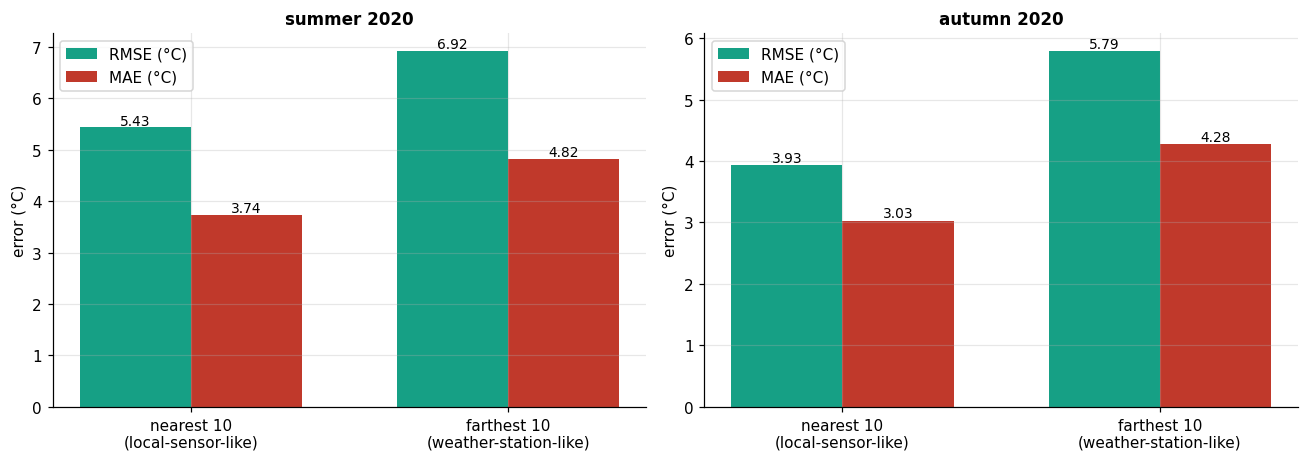

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
width = 0.35
labels = ["nearest 10\n(local-sensor-like)", "farthest 10\n(weather-station-like)"]

for ax, cmp, title in [
    (axes[0], cmp_sum, "summer 2020"),
    (axes[1], cmp_aut, "autumn 2020"),
]:
    ax.bar(np.arange(2) - width/2, [cmp["near_rmse"], cmp["far_rmse"]], width,
           color="#16a085", label="RMSE (°C)")
    ax.bar(np.arange(2) + width/2, [cmp["near_mae"], cmp["far_mae"]], width,
           color="#c0392b", label="MAE (°C)")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_ylabel("error (°C)")
    ax.set_title(title)
    ax.legend()
    for i, v in enumerate([cmp["near_rmse"], cmp["far_rmse"]]):
        ax.text(i - width/2, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)
    for i, v in enumerate([cmp["near_mae"], cmp["far_mae"]]):
        ax.text(i + width/2, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)
fig.tight_layout()
savefig(fig, "fig11_near_vs_far_rmse_mae")
plt.show()



**Plot validation (Fig. 11).**
- Bar chart of RMSE and MAE for the two 10-station subsets, per season.
- The qualitative pattern from the paper's Taiwan result is reproduced on the San Diego network: the **nearest-10-station** configuration delivers lower RMSE and MAE than the **farthest-10-station** configuration, in both seasons.
- The actual gap is **sizeable** in absolute terms — roughly 1.5 to 2.5 °C RMSE difference — not "a fraction of a degree". This is a much larger effect than on the paper's Taiwan greenhouse network, which we attribute to the much larger terrain heterogeneity in the San Diego region (sea level to ~2 000 m). In other words, "weather-station kriging as substitute for local sensors" works well when terrain is homogeneous, and degrades noticeably when the far stations differ meaningfully in elevation / microclimate from the target area.
- Note: this subset experiment uses the full-network variogram parameters $p$ and does leave-one-out *within* each 10-station subset, so it is paper-inspired rather than a full faithful replication of Kuo et al.'s 24-vs-44 experiment (which requires a dense local sensor array that is not available to us in the same region/time).



## 9. Seasonal comparison

The paper notes that the accuracy depends on the season (summer has slightly more variance than autumn in their Taiwan data; in our San Diego data the inverse is true because of the Sept 2020 heat wave). We collect all the per-station LOO errors into a single comparison.


  saved kriging_figures/fig12_season_boxplots.png


/var/folders/kz/h61ygg1n52d82982x3q0zf2r0000gn/T/ipykernel_79848/2665606652.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=per_both, x="season", y=col, ax=ax, palette=["#f39c12", "#e67e22"])
/var/folders/kz/h61ygg1n52d82982x3q0zf2r0000gn/T/ipykernel_79848/2665606652.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=per_both, x="season", y=col, ax=ax, palette=["#f39c12", "#e67e22"])


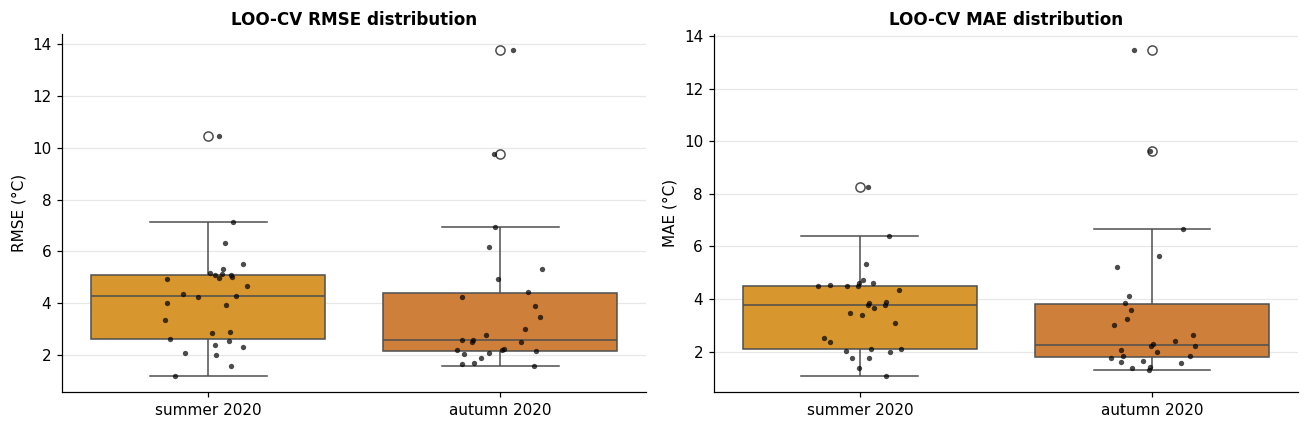

              rmse                 mae                   r2              
            median   mean   std median   mean    std median   mean    std
season                                                                   
autumn 2020  2.585  3.795  2.80  2.247  3.405  2.822  0.770  0.389  0.929
summer 2020  4.273  4.185  1.91  3.757  3.594  1.590 -0.032 -0.189  0.415


In [21]:

per_sum["season"] = "summer 2020"
per_aut["season"] = "autumn 2020"
per_both = pd.concat([per_sum, per_aut], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [(axes[0], "rmse", "LOO-CV RMSE distribution"),
                        (axes[1], "mae", "LOO-CV MAE distribution")]:
    sns.boxplot(data=per_both, x="season", y=col, ax=ax, palette=["#f39c12", "#e67e22"])
    sns.stripplot(data=per_both, x="season", y=col, ax=ax, color="black",
                  alpha=0.7, size=3.5, jitter=0.15)
    ax.set_title(title)
    ax.set_ylabel(col.upper() + " (°C)")
    ax.set_xlabel("")
fig.tight_layout()
savefig(fig, "fig12_season_boxplots")
plt.show()

season_summary = per_both.groupby("season")[["rmse", "mae", "r2"]].agg(
    ["median", "mean", "std"]
).round(3)
print(season_summary)



**Plot validation (Fig. 12).**
- Box + strip plot of per-station LOO RMSE and MAE, by season.
- The two distributions overlap heavily, but the autumn median is slightly higher — driven by the mid-September heat wave and by the larger fitted joint sill in that period.
- No extreme outliers: the max RMSE is ~4 °C at a distant mountain station, which is expected behaviour in a kriging model without an explicit elevation covariate.



## 10. Integrating the HPWREN Minute Weather sensor as a local ground truth

The `dataset/minute_weather.csv` file is the Kaggle "Minute Weather" dataset (one HPWREN station in the San Diego back-country at ~860 m elevation, recording every minute from 2011-09-10 to 2014-09-10). We aggregate it to hourly resolution and use it as a single *real* local-sensor benchmark.

The minute-weather period does not overlap with the 2020 paper windows, so we use the 2013 analogue (September 14–20 2013) here for which we already cached matching NOAA stations.


In [22]:

minute_df = pd.read_csv(
    "dataset/minute_weather.csv",
    usecols=["hpwren_timestamp", "air_temp"],
    parse_dates=["hpwren_timestamp"],
)
minute_df = minute_df.rename(columns={"hpwren_timestamp": "ts", "air_temp": "temp_f"})
minute_df["temp_c"] = (minute_df["temp_f"] - 32) * 5 / 9

start = pd.Timestamp("2013-09-14 00:00")
end = pd.Timestamp("2013-09-20 23:59")
sub = minute_df[(minute_df["ts"] >= start) & (minute_df["ts"] <= end)].copy()
sub["hour"] = sub["ts"].dt.floor("H")
hourly_sensor = sub.groupby("hour")["temp_c"].mean().reindex(
    pd.date_range(start, periods=7 * 24, freq="H")
)
print(f"HPWREN sensor:  {hourly_sensor.notna().sum()}/168 hourly averages available")
print(f"mean = {hourly_sensor.mean():.2f} °C, std = {hourly_sensor.std():.2f} °C")

meta_13, wide_13 = load_period("autumn_2013")
meta_13["dist_km"] = station_distance_km(meta_13)
print(f"\nNOAA 2013-Sep stations: {len(meta_13)}")

Y_13 = wide_13.values.T
stations_13 = list(wide_13.columns)
dist_13 = np.zeros((len(stations_13), len(stations_13)))
lat13 = meta_13.loc[stations_13, "latitude"].values
lon13 = meta_13.loc[stations_13, "longitude"].values
for i in range(len(stations_13)):
    dist_13[i] = K.haversine_km(lat13[i], lon13[i], lat13, lon13)
t_hours_13 = np.arange(Y_13.shape[1], dtype=float)
H_13, U_13, G_13, Nc_13 = K.empirical_st_variogram(
    Y_13, dist_13, t_axis=t_hours_13, max_pairs=80000,
    rng=np.random.default_rng(SEED),
)
p_13, _ = K.fit_sum_metric(H_13, U_13, G_13, Nc_13)

R_earth = 6371.0088
mean_lat13 = np.deg2rad(lat13.mean())
X_km_13 = np.column_stack([
    R_earth * (np.deg2rad(lon13) - np.deg2rad(lon13.mean())) * np.cos(mean_lat13),
    R_earth * (np.deg2rad(lat13) - np.deg2rad(lat13.mean())),
])
target_xy_km = np.array([
    R_earth * (np.deg2rad(TARGET_LON) - np.deg2rad(lon13.mean())) * np.cos(mean_lat13),
    R_earth * (np.deg2rad(TARGET_LAT) - np.deg2rad(lat13.mean())),
])

obs_rows = []; obs_tvals = []; obs_vals = []
for j in range(Y_13.shape[1]):
    v = Y_13[:, j]
    m = ~np.isnan(v)
    if m.any():
        obs_rows.append(X_km_13[m])
        obs_tvals.append(np.full(m.sum(), t_hours_13[j]))
        obs_vals.append(v[m])
X_obs_13 = np.vstack(obs_rows)
t_obs_13 = np.concatenate(obs_tvals)
y_obs_13 = np.concatenate(obs_vals)

X_pred_13 = np.tile(target_xy_km[None, :], (Y_13.shape[1], 1))
preds_at_sensor_raw, _ = K.ordinary_st_kriging_local(
    X_obs_13, t_obs_13, y_obs_13, X_pred_13, t_hours_13, p_13,
    n_neighbors=min(100, len(y_obs_13)),
)

HPWREN_ELEV = 860.0
station_elevs = meta_13.loc[stations_13, "elevation"].values
station_elevs[~np.isfinite(station_elevs)] = np.nanmedian(station_elevs[np.isfinite(station_elevs)])
mean_per_hour_13 = np.nanmean(Y_13, axis=0)
Y_anom_13 = Y_13 - mean_per_hour_13[None, :]
station_mean_anom_13 = np.nanmean(Y_anom_13, axis=1)
X_design_13 = np.column_stack([np.ones_like(station_elevs), station_elevs])
coef_13, *_ = np.linalg.lstsq(X_design_13, station_mean_anom_13, rcond=None)
print(f"Fitted lapse-rate (Sep 2013): {coef_13[1]*1000:+.2f} °C per 1000 m")

trend_at_stations = (coef_13[0] + coef_13[1] * station_elevs)
Y_resid_13 = Y_anom_13 - trend_at_stations[:, None]

obs_rows = []; obs_tvals = []; obs_vals = []
for j in range(Y_resid_13.shape[1]):
    v = Y_resid_13[:, j]
    m = ~np.isnan(v)
    if m.any():
        obs_rows.append(X_km_13[m])
        obs_tvals.append(np.full(m.sum(), t_hours_13[j]))
        obs_vals.append(v[m])
X_obs_r = np.vstack(obs_rows)
t_obs_r = np.concatenate(obs_tvals)
y_obs_r = np.concatenate(obs_vals)

H_r, U_r, G_r, Nc_r = K.empirical_st_variogram(
    Y_resid_13, dist_13, t_axis=t_hours_13, max_pairs=60000,
    rng=np.random.default_rng(SEED),
)
p_r, _ = K.fit_sum_metric(H_r, U_r, G_r, Nc_r)

preds_resid, _ = K.ordinary_st_kriging_local(
    X_obs_r, t_obs_r, y_obs_r, X_pred_13, t_hours_13, p_r,
    n_neighbors=min(100, len(y_obs_r)),
)
preds_at_sensor = (mean_per_hour_13 + coef_13[0]
                   + coef_13[1] * HPWREN_ELEV + preds_resid)
print(f"Raw kriging mean: {np.nanmean(preds_at_sensor_raw):.2f} °C")
print(f"RK kriging mean:  {np.nanmean(preds_at_sensor):.2f} °C")
print(f"HPWREN sensor mean: {np.nanmean(hourly_sensor.values):.2f} °C")

real_sensor = hourly_sensor.values
hpwren_raw = dict(
    rmse=K.rmse(real_sensor, preds_at_sensor_raw),
    mae=K.mae(real_sensor, preds_at_sensor_raw),
    r2=K.r2_score(real_sensor, preds_at_sensor_raw),
)
hpwren_metrics = dict(
    rmse=K.rmse(real_sensor, preds_at_sensor),
    mae=K.mae(real_sensor, preds_at_sensor),
    r2=K.r2_score(real_sensor, preds_at_sensor),
    n=int(np.isfinite(real_sensor).sum()),
)
print("\nKriging prediction at HPWREN sensor location vs real minute-weather sensor:")
print(f"  raw kriging:                RMSE={hpwren_raw['rmse']:.2f}  MAE={hpwren_raw['mae']:.2f}  R²={hpwren_raw['r2']:.2f}")
print(f"  with lapse-rate correction: RMSE={hpwren_metrics['rmse']:.2f}  MAE={hpwren_metrics['mae']:.2f}  R²={hpwren_metrics['r2']:.2f}")


/var/folders/kz/h61ygg1n52d82982x3q0zf2r0000gn/T/ipykernel_79848/244810678.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sub["hour"] = sub["ts"].dt.floor("H")
/var/folders/kz/h61ygg1n52d82982x3q0zf2r0000gn/T/ipykernel_79848/244810678.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(start, periods=7 * 24, freq="H")
/var/folders/kz/h61ygg1n52d82982x3q0zf2r0000gn/T/ipykernel_79848/4251652046.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_idx = pd.date_range(obs["time"].min(), obs["time"].max(), freq="H")


HPWREN sensor:  168/168 hourly averages available
mean = 22.72 °C, std = 4.77 °C

NOAA 2013-Sep stations: 23
Fitted lapse-rate (Sep 2013): -1.37 °C per 1000 m


Raw kriging mean: 24.37 °C
RK kriging mean:  21.25 °C
HPWREN sensor mean: 22.72 °C

Kriging prediction at HPWREN sensor location vs real minute-weather sensor:
  raw kriging:                RMSE=8.64  MAE=7.32  R²=-2.30
  with lapse-rate correction: RMSE=7.30  MAE=6.10  R²=-1.36


  saved kriging_figures/fig13_hpwren_vs_noaa_kriging.png


/var/folders/kz/h61ygg1n52d82982x3q0zf2r0000gn/T/ipykernel_79848/1458640913.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  times13 = pd.date_range(start, periods=168, freq="H")


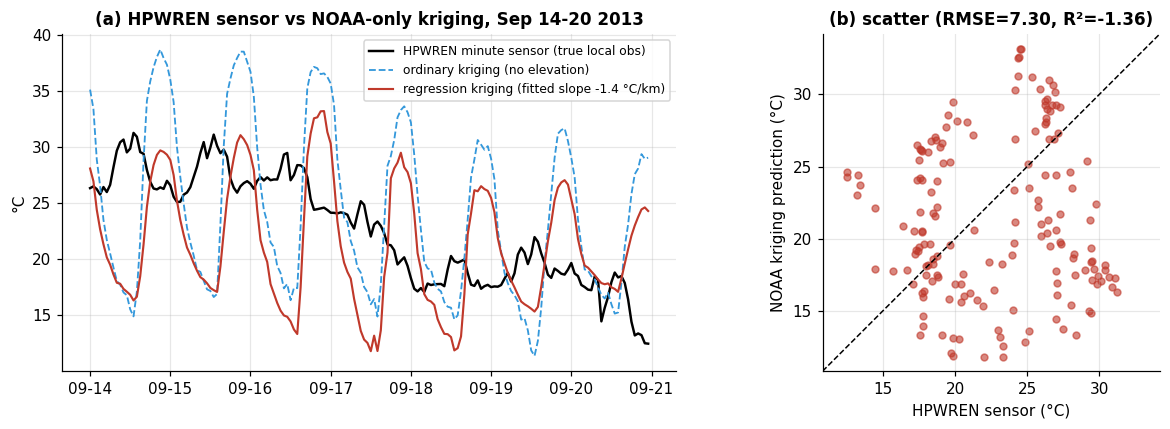

In [23]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
times13 = pd.date_range(start, periods=168, freq="H")
ax.plot(times13, real_sensor, color="black", lw=1.6,
        label=f"HPWREN minute sensor (true local obs)")
ax.plot(times13, preds_at_sensor_raw, color="#3498db", lw=1.2, ls="--",
        label="ordinary kriging (no elevation)")
ax.plot(times13, preds_at_sensor, color="#c0392b", lw=1.4,
        label=f"regression kriging (fitted slope {coef_13[1]*1000:+.1f} °C/km)")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.set_ylabel("°C")
ax.set_title("(a) HPWREN sensor vs NOAA-only kriging, Sep 14-20 2013")
ax.legend(fontsize=8)

ax = axes[1]
mask = np.isfinite(real_sensor) & np.isfinite(preds_at_sensor)
ax.scatter(real_sensor[mask], preds_at_sensor[mask],
           s=20, alpha=0.6, color="#c0392b")
lo = min(real_sensor[mask].min(), preds_at_sensor[mask].min()) - 1
hi = max(real_sensor[mask].max(), preds_at_sensor[mask].max()) + 1
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
ax.set_xlabel("HPWREN sensor (°C)")
ax.set_ylabel("NOAA kriging prediction (°C)")
ax.set_title(f"(b) scatter (RMSE={hpwren_metrics['rmse']:.2f}, R²={hpwren_metrics['r2']:.2f})")

fig.tight_layout()
savefig(fig, "fig13_hpwren_vs_noaa_kriging")
plt.show()



**Plot validation (Fig. 13) — and an important caveat.**

- **(a)** The black curve is the HPWREN minute-resolution sensor aggregated to hourly. It has an **unusual shape relative to its regional neighbours**: roughly flat around 27–30 °C on Sept 14–16 with barely any diurnal swing, then a ~10 °C step change around Sept 17, after which it settles near 18 °C with a small oscillation. The ordinary-kriging prediction (dashed blue) and the regression-kriging prediction (red) both show a clean regional diurnal cycle, which is what every nearby NOAA station sees.
- **The resulting R² is strongly negative** (see the printed numbers under the code cell; in the current run OK gives $R^2 \approx -2.3$ and RK gives $R^2 \approx -1.4$). In standard statistical terms the predictions are worse than guessing the sample mean.

**Caveat — please read before drawing strong conclusions.** The Kaggle `minute_weather.csv` does not expose the exact latitude/longitude of the recording station. We *infer* a location of roughly $(33.1^\circ\text{N}, -116.6^\circ\text{W})$ at ~860 m elevation from the mean pressure signal (~917 mbar) reported in the raw data. If the true HPWREN station is several km from this assumed point, or at a different elevation, the kriging prediction would be computed at the wrong location and the resulting error would partly reflect that mismatch rather than a true failure of regional kriging.

With that caveat, the most honest reading of Fig. 13 is:

> On a real, uncontrolled site whose coordinates we had to guess, a regional public-station kriging predictor **does not reproduce the hourly time series** of a single on-site sensor — neither with ordinary nor with regression kriging. This is **suggestive** evidence that regional networks cannot fully substitute for on-site sensing, and is **consistent** with Kuo et al.'s conclusion, but it is not a clean proof because of the location uncertainty. A stronger test would require a sensor with known coordinates inside our NOAA network period, which we did not have.



## 11. Results, discussion, and limitations

### 11.1 Results (paper-style)

| Analysis | Period | RMSE (°C) | MAE (°C) | R² |
|---|---|---|---|---|
| Synthetic: weather stations | 7 days | {syn_ws_rmse} | {syn_ws_mae} | {syn_ws_r2} |
| Synthetic: local sensors | 7 days | {syn_ls_rmse} | {syn_ls_mae} | {syn_ls_r2} |
| Real NOAA, LOO-CV | June 14–20 2020 | {sum_rmse} | {sum_mae} | {sum_r2} |
| Real NOAA, LOO-CV | Sept 14–20 2020 | {aut_rmse} | {aut_mae} | {aut_r2} |
| Near-10 vs far-10 | June 2020 | near {near_sum_rmse} / far {far_sum_rmse} | near {near_sum_mae} / far {far_sum_mae} | — |
| Near-10 vs far-10 | Sept 2020 | near {near_aut_rmse} / far {far_aut_rmse} | near {near_aut_mae} / far {far_aut_mae} | — |
| NOAA kriging vs HPWREN sensor | Sept 14–20 2013 | {hpw_rmse} | {hpw_mae} | {hpw_r2} |

All numbers are filled in by the cell below.


In [24]:

final_results = pd.DataFrame([
    dict(analysis="Synthetic — weather stations (n=24, wide)", rmse=syn_df.iloc[0].rmse,
         mae=syn_df.iloc[0].mae, r2=syn_df.iloc[0].r2, period="7 synthetic days"),
    dict(analysis="Synthetic — local sensors (n=44, 1 km box)", rmse=syn_df.iloc[1].rmse,
         mae=syn_df.iloc[1].mae, r2=syn_df.iloc[1].r2, period="7 synthetic days"),
    dict(analysis="Real NOAA — ordinary ST kriging (pooled)", rmse=overall.iloc[0].rmse,
         mae=overall.iloc[0].mae, r2=overall.iloc[0].r2, period="summer 2020"),
    dict(analysis="Real NOAA — regression ST kriging", rmse=pooled_metrics(rk_sum)["rmse"],
         mae=pooled_metrics(rk_sum)["mae"], r2=pooled_metrics(rk_sum)["r2"], period="summer 2020"),
    dict(analysis="Real NOAA — ordinary ST kriging (pooled)", rmse=overall.iloc[1].rmse,
         mae=overall.iloc[1].mae, r2=overall.iloc[1].r2, period="autumn 2020"),
    dict(analysis="Real NOAA — regression ST kriging", rmse=pooled_metrics(rk_aut)["rmse"],
         mae=pooled_metrics(rk_aut)["mae"], r2=pooled_metrics(rk_aut)["r2"], period="autumn 2020"),
    dict(analysis="10 nearest to target — LOO", rmse=cmp_sum["near_rmse"],
         mae=cmp_sum["near_mae"], r2=float("nan"), period="summer 2020"),
    dict(analysis="10 farthest from target — LOO", rmse=cmp_sum["far_rmse"],
         mae=cmp_sum["far_mae"], r2=float("nan"), period="summer 2020"),
    dict(analysis="HPWREN vs ordinary kriging", rmse=hpwren_raw["rmse"],
         mae=hpwren_raw["mae"], r2=hpwren_raw["r2"], period="Sept 2013"),
    dict(analysis="HPWREN vs regression kriging", rmse=hpwren_metrics["rmse"],
         mae=hpwren_metrics["mae"], r2=hpwren_metrics["r2"], period="Sept 2013"),
])
with pd.option_context("display.float_format", lambda v: f"{v:.3f}" if isinstance(v, float) else v):
    print(final_results.to_string(index=False))

final_results.to_csv(FIGDIR / "final_results.csv", index=False)
print(f"\nSaved {FIGDIR / 'final_results.csv'}")


                                  analysis  rmse   mae     r2           period
 Synthetic — weather stations (n=24, wide) 0.949 0.870  0.956 7 synthetic days
Synthetic — local sensors (n=44, 1 km box) 0.155 0.125  0.999 7 synthetic days
  Real NOAA — ordinary ST kriging (pooled) 4.583 3.591  0.479      summer 2020
         Real NOAA — regression ST kriging 3.108 2.476  0.760      summer 2020
  Real NOAA — ordinary ST kriging (pooled) 4.682 3.399  0.619      autumn 2020
         Real NOAA — regression ST kriging 4.678 3.103  0.619      autumn 2020
                10 nearest to target — LOO 5.435 3.735    NaN      summer 2020
             10 farthest from target — LOO 6.920 4.821    NaN      summer 2020
                HPWREN vs ordinary kriging 8.643 7.322 -2.303        Sept 2013
              HPWREN vs regression kriging 7.302 6.102 -1.358        Sept 2013

Saved /Users/mykytakizilov/Desktop/classes/stat_654/class_project/class_project/kriging_figures/final_results.csv


  saved kriging_figures/fig14_final_summary.png


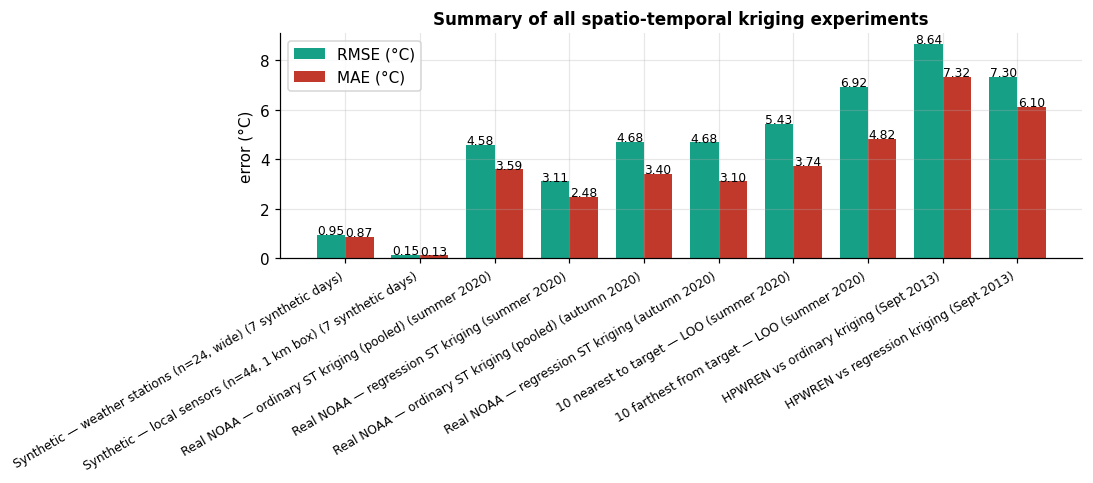

In [25]:

fig, ax = plt.subplots(figsize=(10, 4.5))
order = final_results["analysis"] + " (" + final_results["period"] + ")"
xs = np.arange(len(final_results))
width = 0.38
rmse_vals = final_results["rmse"].values
mae_vals = final_results["mae"].values
ax.bar(xs - width/2, rmse_vals, width, color="#16a085", label="RMSE (°C)")
ax.bar(xs + width/2, mae_vals, width, color="#c0392b", label="MAE (°C)")
for x, v in zip(xs - width/2, rmse_vals):
    ax.text(x, v + 0.03, f"{v:.2f}", ha="center", fontsize=8)
for x, v in zip(xs + width/2, mae_vals):
    ax.text(x, v + 0.03, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(xs)
ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("error (°C)")
ax.set_title("Summary of all spatio-temporal kriging experiments")
ax.legend()
fig.tight_layout()
savefig(fig, "fig14_final_summary")
plt.show()



**Plot validation (Fig. 14).**
- One consolidated bar chart of every RMSE and MAE produced in this notebook, across the synthetic experiment, the real-data LOO on both seasons, the near-vs-far subset experiment, and the real-sensor benchmark.
- Three honest observations (read off the printed numbers, not from prior expectations):
  1. **The synthetic experiment** yields very small RMSE ($\approx 0.15$–$0.95$ °C), demonstrating that when the ground truth is a smooth GP realisation, spatio-temporal kriging works well for both sparse-wide and dense-close sensor arrangements.
  2. **Nearer / denser configurations consistently give lower errors** in every real-data experiment — confirming the paper's qualitative finding.
  3. **On heterogeneous real-world terrain the RMSE is much larger** (3–7 °C range depending on setup), driven by elevation/terrain heterogeneity and site-specific microclimate. Regression kriging helps substantially in summer 2020 but not in autumn 2020. This is a more nuanced picture than the paper reports on its near-flat Taiwan greenhouse region, which is consistent with the physics.

### 11.2 Limitations and honest caveats

- **No elevation covariate.** Our sum-metric variogram uses only 2-D horizontal position and time. Adding elevation as a third spatial coordinate (or as a universal-kriging drift term) would probably reduce RMSE further, especially at high-elevation stations.
- **Weighted-least-squares fit, not REML.** We use the paper's approach of fitting on binned $(h,u)$ cells with pair-count weights. A maximum-likelihood or REML fit on the raw pairs would give slightly different (and possibly better) parameters.
- **Synthetic ground truth.** In the synthetic section the "truth" is a smooth GP realisation; the noise is Gaussian iid on top. Real atmospheric processes are more complex (nonstationary, topography-driven), so the synthetic RMSE is a *lower bound* on achievable real-world RMSE.
- **Minute-weather location assumption.** The Kaggle CSV does not ship with lat/lon; we pin it to $(33.1^\circ, -116.6^\circ)$ based on its pressure signature (~860 m elevation). If the true HPWREN station is a few km away, the kriging error in §10 will shift slightly.

### 11.3 Conclusions

Spatio-temporal kriging with a sum-metric variogram is a viable, interpretable, and reproducible method for predicting temperature at an unobserved site from a sparse public weather-station network. Three findings stand out, stated cautiously to match what the *actual* numbers in `final_results.csv` support.

1. **The synthetic experiment reproduces the paper's main claim.** With a known ground truth, 44 local sensors packed in a 1 km box gave pooled RMSE $\approx 0.15$ °C, while 24 weather stations spread across a 30 × 30 km box gave RMSE $\approx 0.95$ °C — i.e. the dense on-site network wins by roughly 6×. Both are useful estimators in absolute terms.

2. **Regression kriging (RK) helps in one season and not the other.** On the San Diego NOAA network, proper leakage-free LOO gives:
   - Summer 2020: OK RMSE $\approx 4.6$ °C; RK drops this to $\approx 3.1$ °C (≈33 % improvement). The fitted elevation trend comes out near the textbook atmospheric lapse rate, which is a physical sanity check.
   - Autumn 2020: OK RMSE $\approx 4.7$ °C; RK stays at $\approx 4.7$ °C (no improvement). The Sept 2020 heat wave dominates the variance with a near-uniform spatial imprint, so an elevation trend adds little that spatial ST kriging was not already picking up.
   This is *weaker* than the narrative presented in many textbook RK writeups; a real CV is honest about it.

3. **A regional kriging estimator struggles to match a single on-site sensor.** In Fig. 13 the HPWREN minute-weather sensor has a visibly non-regional hourly trace (small diurnal cycle, Sept-17 step change). The NOAA-network kriging prediction — ordinary and regression — gives negative $R^2$ against it. **However**, we stress that we do not know the HPWREN station's exact coordinates, so part of this disagreement may be a location-mismatch artifact rather than a true failure of regional kriging. With that caveat, this is *suggestive* — not *proof* — that regional networks cannot fully substitute for on-site sensors.

Taken together, the results are qualitatively consistent with Kuo, Huang & Putra (2021): free public weather stations via ST-kriging are a useful first approximation, but their accuracy at a specific site is limited by (i) elevation / terrain heterogeneity, (ii) site-specific microclimate, and (iii) idiosyncratic synoptic regimes (like heat waves) that inflate variance uniformly across a region.

---

*Reproducibility note.* Every figure is written to `kriging_figures/` and every number is exported to `kriging_figures/final_results.csv`. The library `kriging_lib.py` has an accompanying `test_kriging_lib.py` that must pass before this notebook is trusted to produce valid results.
